In [1]:
import pandas as pd
df = pd.read_csv("DS-jobs.csv")


Data Cleaning and Preprocessing

In [2]:
df.head()


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


Data Cleaning and Preprocessing
1. Detailed Parsing of Salary Information:

• Remove Currency Symbols: Remove ”$” or other currency sym-
bols from ”Salary Estimate” to simplify the salary parsing process.

• Salary Type Extraction: Create a column that identifies whether

the salary is presented as ”per year,” ”per hour,” etc., based on com-
mon indicators in ”Salary Estimate.”

2. Handle Special Characters in Text Columns:
• Text Standardization: Remove or replace special characters (e.g.,
”\n”, ”\t”, and other symbols) from columns like ”Job Description”
and ”Company Name” for consistency.

• Lowercasing: Convert all text columns (e.g., ”Job Title,” ”Com-
pany Name,” ”Industry”) to lowercase to standardize the format and

avoid case sensitivity issues during analysis.
3. Company Name Refinement:
• Remove Rating from Company Name: Clean up ”Company
Name” by removing any appended rating values (e.g., ”Company
Name\n3.8”).
• Unique Company Identifier: Generate a unique identifier for each

company based on the cleaned ”Company Name” to help with com-
parisons.

4. Standardizing Location Data:
• Expand State Abbreviations: For the ”Location” column, expand
state abbreviations (e.g., ”CA” → ”California”) to ensure uniformity.

• Location Format Consistency: Check for any inconsistent for-
mats in ”Location” and ”Headquarters” and standardize to ”City,

State” format.
• Distance Calculation: If city and state information are available,
create approximate distance calculations between ”Location” and
”Headquarters” to identify remote positions.
5. Revenue Column Parsing and Cleaning:
• Extract Revenue Range: For each value in ”Revenue,” extract
minimum and maximum revenue values to separate columns.
• Currency Standardization: Ensure all revenue values are in the

same currency (e.g., USD) and handle conversions if any foreign cur-
rencies are detected.

• Fill Missing Values in Revenue: Fill missing values in the ”Rev-
enue” column.

In [3]:

df['Salary Type'] = df['Salary Estimate'].apply(lambda x: 'per hour' if 'per hour' in x.lower() else ('per year' if 'per year' in x.lower() else ('per day' if 'per day' in x.lower() else 'per year')))
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Type
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",per year
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,per year
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,per year
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",per year
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",per year


In [4]:
#1
df['Salary Estimate'] = df['Salary Estimate'].str.replace('[£$€₹]', '',regex=True)
df['Salary Estimate']=df['Salary Estimate'].str.replace("K","000")

df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Type
0,0,Sr Data Scientist,137000-171000 (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",per year
1,1,Data Scientist,137000-171000 (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,per year
2,2,Data Scientist,137000-171000 (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,per year
3,3,Data Scientist,137000-171000 (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",per year
4,4,Data Scientist,137000-171000 (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",per year


In [5]:


#2
import re
def remove_special_char(Text):
  cleaned_text=re.sub(r"[^a-zA-Z0-9]","",Text)
  cleaned_text=re.sub(r"\s+","",cleaned_text)
  return cleaned_text


  df["Job Description"]=df["Job Description"].apply(remove_special_char)


  df["Company Name"]=df["Company Name"].apply(remove_special_char)





In [6]:
  df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Type
0,0,Sr Data Scientist,137000-171000 (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",per year
1,1,Data Scientist,137000-171000 (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,per year
2,2,Data Scientist,137000-171000 (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,per year
3,3,Data Scientist,137000-171000 (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",per year
4,4,Data Scientist,137000-171000 (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",per year


In [7]:
df["Job Description"]=df["Job Description"].str.replace("\n",' ',regex=True).str.replace("\t","",regex=True).str.replace("\r","",regex=True)
df["Company Name"]=df["Company Name"].str.replace("\n",' ',regex=True).str.replace("\t","",regex=True).str.replace("\r","",regex=True)
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Type
0,0,Sr Data Scientist,137000-171000 (Glassdoor est.),Description The Senior Data Scientist is resp...,3.1,Healthfirst 3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",per year
1,1,Data Scientist,137000-171000 (Glassdoor est.),"Secure our Nation, Ignite your Future Join th...",4.2,ManTech 4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1,per year
2,2,Data Scientist,137000-171000 (Glassdoor est.),Overview Analysis Group is one of the larges...,3.8,Analysis Group 3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1,per year
3,3,Data Scientist,137000-171000 (Glassdoor est.),JOB DESCRIPTION: Do you have a passion for Da...,3.5,INFICON 3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",per year
4,4,Data Scientist,137000-171000 (Glassdoor est.),Data Scientist Affinity Solutions / Marketing ...,2.9,Affinity Solutions 2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",per year


In [8]:
df=df.apply(lambda x:x.str.lower() if x.dtype=='object' else x)
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Type
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst 3.1,"new york, ny","new york, ny",1001 to 5000 employees,1993,nonprofit organization,insurance carriers,insurance,unknown / non-applicable,"emblemhealth, unitedhealth group, aetna",per year
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech 4.2,"chantilly, va","herndon, va",5001 to 10000 employees,1968,company - public,research & development,business services,$1 to $2 billion (usd),-1,per year
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group 3.8,"boston, ma","boston, ma",1001 to 5000 employees,1981,private practice / firm,consulting,business services,$100 to $500 million (usd),-1,per year
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon 3.5,"newton, ma","bad ragaz, switzerland",501 to 1000 employees,2000,company - public,electrical & electronic manufacturing,manufacturing,$100 to $500 million (usd),"mks instruments, pfeiffer vacuum, agilent tech...",per year
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions 2.9,"new york, ny","new york, ny",51 to 200 employees,1998,company - private,advertising & marketing,business services,unknown / non-applicable,"commerce signals, cardlytics, yodlee",per year


In [9]:
#3
df["Company Name"] = df.apply(lambda x: x["Company Name"].replace(str(x["Rating"]), "", 1) if str(x["Rating"]) in x["Company Name"] else x["Company Name"], axis=1)

In [10]:
company_ids = {}
def create_company_id(company_name):
  if company_name not in company_ids:
    company_ids[company_name]=len(company_ids)+1
  return company_ids[company_name]




In [11]:
df["Company ID"]=df["Company Name"].apply(create_company_id)
df.tail()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Type,Company ID
667,667,data scientist,105000-167000 (glassdoor est.),summary we’re looking for a data scientist to...,3.6,tranzact,"fort lee, nj","fort lee, nj",1001 to 5000 employees,1989,company - private,advertising & marketing,business services,unknown / non-applicable,-1,per year,432
668,668,data scientist,105000-167000 (glassdoor est.),job description become a thought leader within...,-1.0,jkgt,"san francisco, ca",-1,-1,-1,-1,-1,-1,-1,-1,per year,433
669,669,data scientist,105000-167000 (glassdoor est.),join a thriving company that is changing the w...,-1.0,accesshope,"irwindale, ca",-1,-1,-1,-1,-1,-1,-1,-1,per year,434
670,670,data scientist,105000-167000 (glassdoor est.),100 remote opportunity as an ainlp data scient...,5.0,chateck incorporated,"san francisco, ca","santa clara, ca",1 to 50 employees,-1,company - private,advertising & marketing,business services,$1 to $5 million (usd),-1,per year,435
671,671,data scientist,105000-167000 (glassdoor est.),description the data scientist will be part o...,2.7,1-800-flowers,"new york, ny","carle place, ny",1001 to 5000 employees,1976,company - public,wholesale,business services,$1 to $2 billion (usd),-1,per year,365


In [12]:
#4
us_state_abbrev = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'DC': 'District of Columbia',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois',
    'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana',
    'ME': 'Maine', 'MD': 'Maryland', 'MA': 'Massachusetts', 'MI': 'Michigan',
    'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana',
    'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota',
    'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania',
    'RI': 'Rhode Island', 'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee',
    'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia',
    'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}

df["Location"]=df["Location"].apply(lambda x:', '.join([x.split(', ')[0],us_state_abbrev.get(x.upper().split(', ')[1],x.split(', ')[1])]) if len(x.split(', '))>1 else (x if x else ' ') )



In [13]:
df["Headquarters"]=df["Headquarters"].apply(lambda x:', '.join([x.split(', ')[0],us_state_abbrev.get(x.upper().split(', ')[1],x.split(', ')[1])]) if len(x.split(', '))>1 else (x if x else ' ') )
df=df.apply(lambda x:x.str.lower() if x.dtype=='object' else x)
df.tail()


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Type,Company ID
667,667,data scientist,105000-167000 (glassdoor est.),summary we’re looking for a data scientist to...,3.6,tranzact,"fort lee, new jersey","fort lee, new jersey",1001 to 5000 employees,1989,company - private,advertising & marketing,business services,unknown / non-applicable,-1,per year,432
668,668,data scientist,105000-167000 (glassdoor est.),job description become a thought leader within...,-1.0,jkgt,"san francisco, california",-1,-1,-1,-1,-1,-1,-1,-1,per year,433
669,669,data scientist,105000-167000 (glassdoor est.),join a thriving company that is changing the w...,-1.0,accesshope,"irwindale, california",-1,-1,-1,-1,-1,-1,-1,-1,per year,434
670,670,data scientist,105000-167000 (glassdoor est.),100 remote opportunity as an ainlp data scient...,5.0,chateck incorporated,"san francisco, california","santa clara, california",1 to 50 employees,-1,company - private,advertising & marketing,business services,$1 to $5 million (usd),-1,per year,435
671,671,data scientist,105000-167000 (glassdoor est.),description the data scientist will be part o...,2.7,1-800-flowers,"new york, new york","carle place, new york",1001 to 5000 employees,1976,company - public,wholesale,business services,$1 to $2 billion (usd),-1,per year,365


In [14]:
!pip install --upgrade --force-reinstall geocoder

  Using cached geocoder-1.38.1-py2.py3-none-any.whl.metadata (14 kB)
  Using cached click-8.1.7-py3-none-any.whl.metadata (3.0 kB)
  Using cached future-1.0.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached ratelim-0.1.6-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached six-1.16.0-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
  Using cached decorator-5.1.1-py3-none-any.whl.metadata (4.0 kB)
  Using cached charset_normalizer-3.4.0-cp312-cp312-win_amd64.whl.metadata (34 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached urllib3-2.2.3-py3-none-any.whl.metadata (6.5 kB)
  Using cached certifi-2024.8.30-py3-none-any.whl.metadata (2.2 kB)
Using cached geocoder-1.38.1-py2.py3-none-any.whl (98 kB)
Using cached click-8.1.7-py3-none-any.whl (97 kB)
Using cached future-1.0.0-py3-none-any.whl (491 kB)
Using cached ratelim-0.1.6-py2.py3-none

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
arcgis 2.4.0 requires requests<2.32.0,>=2.30.0, but you have requests 2.32.3 which is incompatible.


In [ ]:
#5
!pip install haversine
import geocoder
import haversine as hs
import time

def calculate_distance(row):
    location = row['Location']
    headquarters = row['Headquarters']

    
    try:
        location_coords = geocoder.arcgis(location, timeout=10).latlng
        time.sleep(1)  
        hq_coords = geocoder.arcgis(headquarters, timeout=10).latlng
    except Exception as e:
        print(f"Error geocoding {location} or {headquarters}: {e}")
        return None

    if location_coords and hq_coords:
       
        distance = hs.haversine(location_coords, hq_coords, unit=hs.Unit.MILES)
        return distance
    else:
        return None  


df['Distance'] = df.apply(calculate_distance, axis=1)


df['Remote'] = df['Distance'] > 50

In [ ]:
df.head()

In [ ]:
df["Remote"] = df["Remote"].apply(lambda x: "yes" if x else "no")
df.head()

In [14]:
df["Revenue"] = df["Revenue"].str.replace("unknown / non-applicable", "", regex=True)

In [15]:
df.head(632)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Type,Company ID
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,nonprofit organization,insurance carriers,insurance,,"emblemhealth, unitedhealth group, aetna",per year,1
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,company - public,research & development,business services,$1 to $2 billion (usd),-1,per year,2
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,private practice / firm,consulting,business services,$100 to $500 million (usd),-1,per year,3
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,company - public,electrical & electronic manufacturing,manufacturing,$100 to $500 million (usd),"mks instruments, pfeiffer vacuum, agilent tech...",per year,4
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,company - private,advertising & marketing,business services,,"commerce signals, cardlytics, yodlee",per year,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,627,data scientist,87000-141000 (glassdoor est.),job description data scientist location: the ...,4.6,murray resources,"the woodlands, texas","houston, texas",1 to 50 employees,1988,company - private,staffing & outsourcing,business services,$10 to $25 million (usd),-1,per year,348
628,628,data scientist,87000-141000 (glassdoor est.),"geotab, a global leader in iot and connected t...",4.3,geotab,"oakville, california","oakville, canada",1001 to 5000 employees,2000,company - private,computer hardware & software,information technology,$100 to $500 million (usd),-1,per year,415
629,629,data scientist,87000-141000 (glassdoor est.),job description data scientist duration: 6+ mo...,4.7,crs group,"chicago, illinois","itasca, illinois",51 to 200 employees,1994,company - private,staffing & outsourcing,business services,$10 to $25 million (usd),-1,per year,352
630,630,data scientist,87000-141000 (glassdoor est.),"eglobaltech, one of northern virginia’s fastes...",3.7,eglobaltech,"arlington, virginia","vienna, virginia",201 to 500 employees,2004,company - private,it services,information technology,,-1,per year,416


In [16]:
import re

def handle_specific_revenue_formats(revenue_str):
   
    pattern_mixed_range = r'\$(\d+([.,]\d+)?)\s*(million|billion)?\s*(to|-)\s*\$?(\d+([.,]\d+)?)?\s*(million|billion)?'
    match_mixed_range = re.search(pattern_mixed_range, str(revenue_str), re.IGNORECASE)

    if match_mixed_range:
        min_revenue = float(match_mixed_range.group(1).replace(',', ''))
        min_unit = match_mixed_range.group(3)
        max_revenue = float(match_mixed_range.group(5).replace(',', '')) if match_mixed_range.group(5) else min_revenue
        max_unit = match_mixed_range.group(7)

        
        if min_unit and min_unit.lower() == 'billion':
            min_revenue *= 1000
        if max_unit and max_unit.lower() == 'billion':
            max_revenue *= 1000

        return min_revenue, max_revenue

    
    pattern_plus_billion = r'\$(\d+)\+\s*billion'
    match_plus_billion = re.search(pattern_plus_billion, str(revenue_str), re.IGNORECASE)

    if match_plus_billion:
        min_revenue = float(match_plus_billion.group(1)) * 1000  
        return min_revenue, min_revenue  

    
    pattern_less_than_million = r'less than \$1 million'
    match_less_than_million = re.search(pattern_less_than_million, str(revenue_str), re.IGNORECASE)

    if match_less_than_million:
        return 0, 1  

  
    return float('nan'), float('nan')

df[['MinRevenue', 'MaxRevenue']] = df['Revenue'].apply(lambda x: pd.Series(handle_specific_revenue_formats(x)))

In [17]:
df['MaxRevenue']=df['MaxRevenue'].astype(str)
df['MinRevenue']=df['MinRevenue'].astype(str)
df['MinRevenue'].dtype

dtype('O')

In [18]:
import re

df["MinRevenue"] = df.apply(lambda x: re.sub(r"\.0$", "b", x["MinRevenue"]) if "billion" in x['Revenue'] else x['MinRevenue'], axis=1)
df["MaxRevenue"] = df.apply(lambda x: re.sub(r"\.0$", "b", x["MaxRevenue"]) if "billion" in x['Revenue'] else x['MaxRevenue'], axis=1)
df["MinRevenue"] = df.apply(lambda x: re.sub(r"\.0$", "m", x["MinRevenue"]) if "million" in x['Revenue'] else x['MinRevenue'], axis=1)
df["MaxRevenue"] = df.apply(lambda x: re.sub(r"\.0$", "m", x["MaxRevenue"]) if "million" in x['Revenue'] else x['MaxRevenue'], axis=1)
df.head()


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Type,Company ID,MinRevenue,MaxRevenue
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,nonprofit organization,insurance carriers,insurance,,"emblemhealth, unitedhealth group, aetna",per year,1,nan,nan
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,company - public,research & development,business services,$1 to $2 billion (usd),-1,per year,2,1b,2000b
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,private practice / firm,consulting,business services,$100 to $500 million (usd),-1,per year,3,100m,500m
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,company - public,electrical & electronic manufacturing,manufacturing,$100 to $500 million (usd),"mks instruments, pfeiffer vacuum, agilent tech...",per year,4,100m,500m
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,company - private,advertising & marketing,business services,,"commerce signals, cardlytics, yodlee",per year,5,nan,nan


6. Missing Data Handling:
• Fill Missing Values in Categorical Columns: Fill missing values
in columns such as ”Industry” and ”Sector.”
• Fill Missing Values in Rating: Fill missing values in ”Rating.”
7. Cleaning and Extracting Data from ”Job Description”:
• Length Calculation: Create a column to calculate the word count
or character length of each ”Job Description” to help filter lengthy
descriptions.
• Remote Work Flag: Identify if the job allows remote work by
checking for keywords (like ”remote,” ”telecommute”) in the ”Job
Description”.

• Experience Level Parsing: Add columns to identify required ex-
perience levels (e.g., ”entry level,” ”5+ years”) by parsing ”Job De-
scription.”

8. Additional Column Standardization:
• Numeric Conversion of Founding Year: Ensure ”Founded” is a
numeric column, and set a minimum year threshold (e.g., 1800) to
filter out any erroneous entries.
• Size Categorization: For ”Size,” create size categories (e.g.,
”small,” ”medium,” ”large”) based on ranges in employee count.
9. Outlier Detection and Handling:

• Salary Outliers: Detect outliers in the salary range and flag unusu-
ally high or low salary estimates for each job title.

• Rating Outliers: Identify extreme ratings (e.g., below 2.0 or above
4.5) and flag them to verify their accuracy.

• Founded Year Outliers: Flag companies with founding years out-
side a realistic range as potential data entry errors.

10. Column Optimization and Data Type Conversion:
• Convert Numerical Columns: Ensure columns like ”Rating” and
”Founded” are in a suitable numeric format (int64 or float64) and
convert others as appropriate.

• Memory Optimization: Downcast numeric columns (e.g., ”Rat-
ing,” ”Founded”) to the smallest integer or float type without data

loss to optimize memory usage.

In [19]:

df.head(632)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Type,Company ID,MinRevenue,MaxRevenue
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,nonprofit organization,insurance carriers,insurance,,"emblemhealth, unitedhealth group, aetna",per year,1,nan,nan
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,company - public,research & development,business services,$1 to $2 billion (usd),-1,per year,2,1b,2000b
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,private practice / firm,consulting,business services,$100 to $500 million (usd),-1,per year,3,100m,500m
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,company - public,electrical & electronic manufacturing,manufacturing,$100 to $500 million (usd),"mks instruments, pfeiffer vacuum, agilent tech...",per year,4,100m,500m
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,company - private,advertising & marketing,business services,,"commerce signals, cardlytics, yodlee",per year,5,nan,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,627,data scientist,87000-141000 (glassdoor est.),job description data scientist location: the ...,4.6,murray resources,"the woodlands, texas","houston, texas",1 to 50 employees,1988,company - private,staffing & outsourcing,business services,$10 to $25 million (usd),-1,per year,348,10m,25m
628,628,data scientist,87000-141000 (glassdoor est.),"geotab, a global leader in iot and connected t...",4.3,geotab,"oakville, california","oakville, canada",1001 to 5000 employees,2000,company - private,computer hardware & software,information technology,$100 to $500 million (usd),-1,per year,415,100m,500m
629,629,data scientist,87000-141000 (glassdoor est.),job description data scientist duration: 6+ mo...,4.7,crs group,"chicago, illinois","itasca, illinois",51 to 200 employees,1994,company - private,staffing & outsourcing,business services,$10 to $25 million (usd),-1,per year,352,10m,25m
630,630,data scientist,87000-141000 (glassdoor est.),"eglobaltech, one of northern virginia’s fastes...",3.7,eglobaltech,"arlington, virginia","vienna, virginia",201 to 500 employees,2004,company - private,it services,information technology,,-1,per year,416,nan,nan


In [20]:
#6
empty_values = df[df["Rating"] == ""]

numeric_values = df[pd.to_numeric(df["Rating"], errors='coerce').notnull()]

unknown_values = df[df["Rating"].isnull()]

all_problematic_values = pd.concat([empty_values, numeric_values, unknown_values])
print(all_problematic_values["Rating"].unique())

[ 3.1  4.2  3.8  3.5  2.9  3.9  4.4  3.6  4.5  4.7  3.7  3.4  4.1  3.2
  4.3  2.8  5.   4.8  3.3  2.7  2.2  2.6  4.   2.5  4.9  2.4 -1.   2.3
  4.6  3.   2.1  2. ]


In [21]:
import numpy as np
df['Sector'] = df['Sector'].fillna(np.nan)
df['Industry'] = df['Industry'].fillna(np.nan)
df['Rating'] = df['Rating'].fillna(np.nan)

In [22]:
df["Rating"] = df["Rating"].apply(lambda x: str(x).replace(".","",1) if str(x).endswith(".") and str(x)[:-1].isdigit() else x)

In [23]:

df["Rating"] = df["Rating"].apply(lambda x: str(x).replace("-","",1) if str(x).startswith(".") and str(x)[:-1].isdigit() else x)

In [24]:
#7
df['Job Description Length (Words)'] = df['Job Description'].apply(lambda x: len(str(x).split()))
df['Job Description Length (Characters)'] = df['Job Description'].apply(lambda x: len(str(x)))

In [24]:
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Industry,Sector,Revenue,Competitors,Salary Type,Company ID,MinRevenue,MaxRevenue,Job Description Length (Words),Job Description Length (Characters)
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,insurance carriers,insurance,unknown / non-applicable,"emblemhealth, unitedhealth group, aetna",per year,1,nan,nan,469,3389
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,research & development,business services,$1 to $2 billion (usd),-1,per year,2,1b,2000b,542,4076
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,consulting,business services,$100 to $500 million (usd),-1,per year,3,100m,500m,1262,8749
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,electrical & electronic manufacturing,manufacturing,$100 to $500 million (usd),"mks instruments, pfeiffer vacuum, agilent tech...",per year,4,100m,500m,452,3349
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,advertising & marketing,business services,unknown / non-applicable,"commerce signals, cardlytics, yodlee",per year,5,nan,nan,378,2728


In [26]:
filtered_words = df[df['Job Description Length (Words)'] < 500]
filtered_words

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Industry,Sector,Revenue,Competitors,Salary Type,Company ID,MinRevenue,MaxRevenue,Job Description Length (Words),Job Description Length (Characters)
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,insurance carriers,insurance,,"emblemhealth, unitedhealth group, aetna",per year,1,nan,nan,469,3389
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,electrical & electronic manufacturing,manufacturing,$100 to $500 million (usd),"mks instruments, pfeiffer vacuum, agilent tech...",per year,4,100m,500m,452,3349
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,advertising & marketing,business services,,"commerce signals, cardlytics, yodlee",per year,5,nan,nan,378,2728
7,7,data scientist,137000-171000 (glassdoor est.),introduction have you always wanted to run ex...,3.5,irobot,"bedford, massachusetts","bedford, massachusetts",1001 to 5000 employees,1990,...,consumer electronics & appliances stores,retail,$1 to $2 billion (usd),-1,per year,8,1b,2000b,250,1736
8,8,staff data scientist - analytics,137000-171000 (glassdoor est.),intuit is seeking a staff data scientist to co...,4.4,intuit - data,"san diego, california","mountain view, california",5001 to 10000 employees,1983,...,computer hardware & software,information technology,$2 to $5 billion (usd),"square, paypal, h&r block",per year,9,2b,5000b,68,456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,665,data scientist,105000-167000 (glassdoor est.),criterion systems seeks a data scientist to su...,3.8,"criterion systems, inc.","vienna, virginia","vienna, virginia",201 to 500 employees,2005,...,it services,information technology,$50 to $100 million (usd),-1,per year,430,50m,100m,344,2667
668,668,data scientist,105000-167000 (glassdoor est.),job description become a thought leader within...,-1.0,jkgt,"san francisco, california",-1,-1,-1,...,-1,-1,-1,-1,per year,433,nan,nan,162,1251
669,669,data scientist,105000-167000 (glassdoor est.),join a thriving company that is changing the w...,-1.0,accesshope,"irwindale, california",-1,-1,-1,...,-1,-1,-1,-1,per year,434,nan,nan,393,2793
670,670,data scientist,105000-167000 (glassdoor est.),100 remote opportunity as an ainlp data scient...,5.0,chateck incorporated,"san francisco, california","santa clara, california",1 to 50 employees,-1,...,advertising & marketing,business services,$1 to $5 million (usd),-1,per year,435,1m,5m,455,3426


In [27]:
remote_work = df.apply(lambda x: x["Company ID"] if "remote" in x["Job Description"] else None, axis=1)
remote_work.dropna(inplace=True)
remote_work




14      15.0
17      18.0
34      33.0
53      52.0
70      67.0
       ...  
654    359.0
655    361.0
667    432.0
670    435.0
671    365.0
Length: 63, dtype: float64

In [28]:
import re

df["Experience Level"] = df["Job Description"].apply(lambda x: \
    "entry level" if re.search(r"(entry\s?level|junior|graduate)", x, re.IGNORECASE) else \
    "mid level" if re.search(r"(mid\s?level|intermediate|3-5\s?years|3\+? years|4-6\s?years|4\+? years|5-7\s?years|5\+? years)", x, re.IGNORECASE) else \
    "senior level" if re.search(r"(senior|lead|principal|manager|director|executive|7\+? years|8\+? years|9\+? years|10\+? years)", x, re.IGNORECASE) else \
    "Unknown")


In [29]:
#8
df["Founded"] = pd.to_numeric(df["Founded"], errors='coerce') 
df["Founded"] = df["Founded"].apply(lambda x: x if x >= 1800 else np.nan)

In [30]:
import numpy as np

def categorize_size(size_str):
  
    try:
        
        size_num = int(''.join(filter(str.isdigit, size_str.split()[0])))  
        if size_num <= 1000:
            return "small"
        elif 1001 <= size_num <= 5000:
            return "medium"
        elif size_num > 5000:
            return "large"
    except ValueError:
        return np.nan  

df['Size Category'] = df['Size'].apply(categorize_size)

In [31]:
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Revenue,Competitors,Salary Type,Company ID,MinRevenue,MaxRevenue,Job Description Length (Words),Job Description Length (Characters),Experience Level,Size Category
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993.0,...,,"emblemhealth, unitedhealth group, aetna",per year,1,nan,nan,469,3389,senior level,medium
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968.0,...,$1 to $2 billion (usd),-1,per year,2,1b,2000b,542,4076,mid level,large
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981.0,...,$100 to $500 million (usd),-1,per year,3,100m,500m,1262,8749,senior level,medium
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000.0,...,$100 to $500 million (usd),"mks instruments, pfeiffer vacuum, agilent tech...",per year,4,100m,500m,452,3349,Unknown,small
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998.0,...,,"commerce signals, cardlytics, yodlee",per year,5,nan,nan,378,2728,senior level,small


In [32]:
#9
def is_salary_outlier(row):
    
    job_title = row['Job Title']
    
    
    try:
        salary = pd.to_numeric(row['Salary Estimate'])
    except ValueError:
        return False  

    job_data = df[df['Job Title'] == job_title]['Salary Estimate']
    
    job_data = pd.to_numeric(job_data, errors='coerce')
    
    
    mean_salary = job_data.mean()
    std_salary = job_data.std()
    threshold = 2

    return abs(salary - mean_salary) > threshold * std_salary

df['Salary Outlier'] = df.apply(is_salary_outlier, axis=1)

df['Rating Outlier'] = df['Rating'].apply(lambda rating: (rating < 2.0) or (rating > 4.5))

current_year = 2024
df['Founded Year Outlier'] = df['Founded'].apply(lambda year: (year < 1800) or (year > current_year))


In [33]:
df["MinRevenue"]=df["MinRevenue"].replace('m','000000',regex=True).replace('b','000000000',regex=True)
df["MaxRevenue"]=df["MaxRevenue"].replace('m','000000',regex=True).replace('b','000000000',regex=True)


df['MinRevenue'] = df['MinRevenue'].replace(r'\D+', '', regex=True)
df['MaxRevenue'] = df['MaxRevenue'].replace(r'\D+', '', regex=True)

In [34]:
#10
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce').astype('float64')
df['Founded'] = pd.to_numeric(df['Founded'], errors='coerce').astype('Int64')
df['MinRevenue']=pd.to_numeric(df['MinRevenue'], errors='coerce').astype(pd.Int64Dtype())
df['MaxRevenue']=pd.to_numeric(df['MaxRevenue'], errors='coerce').astype(pd.Int64Dtype())

In [35]:

df['index'] = pd.to_numeric(df['index'], errors='coerce').astype(pd.Int32Dtype())
df['Company ID'] = pd.to_numeric(df['Company ID'], errors='coerce').astype(pd.Int32Dtype())
df['Job Description Length (Words)'] = pd.to_numeric(df['Job Description Length (Words)'], errors='coerce').astype(pd.Int32Dtype())
df['Job Description Length (Characters)'] = pd.to_numeric(df['Job Description Length (Characters)'], errors='coerce').astype(pd.Int32Dtype())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   index                                672 non-null    Int32  
 1   Job Title                            672 non-null    object 
 2   Salary Estimate                      672 non-null    object 
 3   Job Description                      672 non-null    object 
 4   Rating                               672 non-null    Float32
 5   Company Name                         672 non-null    object 
 6   Location                             672 non-null    object 
 7   Headquarters                         672 non-null    object 
 8   Size                                 672 non-null    object 
 9   Founded                              551 non-null    Int32  
 10  Type of ownership                    672 non-null    object 
 11  Industry                        

In [36]:
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Company ID,MinRevenue,MaxRevenue,Job Description Length (Words),Job Description Length (Characters),Experience Level,Size Category,Salary Outlier,Rating Outlier,Founded Year Outlier
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,1,<NA>,<NA>,469,3389,senior level,medium,False,False,False
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,2,1000000000,2000000000000,542,4076,mid level,large,False,False,False
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,3,100000000,500000000,1262,8749,senior level,medium,False,False,False
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,4,100000000,500000000,452,3349,Unknown,small,False,False,False
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,5,<NA>,<NA>,378,2728,senior level,small,False,False,False


Exploratory Data Analysis (EDA)

In [37]:
#1

def extract_salary_range(salary_estimate):
    try:
        salary_range = salary_estimate.split('-') 
        min_salary = int(salary_range[0]) 
        max_salary = int(salary_range[1].split(" ")[0])
        return (min_salary + max_salary) / 2 
    except (AttributeError, ValueError, IndexError):
        return np.nan  
df['Average Salary'] = df['Salary Estimate'].apply(extract_salary_range)


salary_stats = df.groupby(['Job Title', 'Industry', 'Sector'])['Average Salary'].agg(['median', 'mean', 'std'])

print(salary_stats)

                                                                                                                        median  \
Job Title                                          Industry                                Sector                                
(sr.) data scientist -                             banks & credit unions                   finance                    109500.0   
ai data scientist                                  federal agencies                        government                  99500.0   
ai ops data scientist                              biotech & pharmaceuticals               biotech & pharmaceuticals  114000.0   
ai/ml - machine learning scientist, siri unders... computer hardware & software            information technology     123500.0   
analytics - business assurance data analyst        lending                                 finance                    118750.0   
...                                                                                       

In [38]:
mean_sal =df.groupby('Company Name')['Average Salary'].mean()
sort = mean_sal.sort_values(ascending=False)
sort.dropna(inplace=True)
highest_average_companies = sort.head(6)
Lowest_average_companies = sort.tail(6)

Lowest_average_companies

Company Name
fleetcor                  43500.0
radiant digital           43500.0
trexquant investment      43500.0
intellipro group inc.     43500.0
apex systems              43500.0
linquest                  43500.0
Name: Average Salary, dtype: float64

In [39]:
rating_category = df['Rating'].apply(lambda x: '< 3.0' if x < 3.0 else ('3.0 - 4.0' if 3.0 <= x <= 4.0 else '> 4.0'))
total_companies = len(df)
rating_proportions = {
    category: rating_category.apply(lambda x: x == category).sum() / total_companies
    for category in ['< 3.0', '3.0 - 4.0', '> 4.0']
}

print("Proportion of Companies in Rating Ranges:")
for label, proportion in rating_proportions.items():
    print(f"{label}: {proportion:.2%}")

Proportion of Companies in Rating Ranges:
< 3.0: 13.10%
3.0 - 4.0: 53.42%
> 4.0: 33.48%


In [40]:
#2
industry_counts = df.groupby('Sector')['Industry'].nunique()
total_unique_industries = df['Industry'].nunique()
industry_proportions = industry_counts / total_unique_industries
print("Number of Unique Industries within Each Sector:")
print(industry_counts)
print("\nProportion of Industries within Each Sector:")
print(industry_proportions)


Number of Unique Industries within Each Sector:
Sector
-1                                    1
accounting & legal                    1
aerospace & defense                   1
agriculture & forestry                2
biotech & pharmaceuticals             1
business services                     6
construction, repair & maintenance    1
consumer services                     1
education                             1
finance                               5
government                            2
health care                           1
information technology                4
insurance                             2
manufacturing                         7
media                                 3
non-profit                            1
oil, gas, energy & utilities          3
real estate                           1
retail                                4
telecommunications                    3
transportation & logistics            5
travel & tourism                      2
Name: Industry, dtype: in

In [41]:
df['Industry']=df['Industry'].fillna(np.nan)
df['Industry']=df['Industry'].dropna()
data_science_df = df[df['Job Title'].str.contains('data scientist', na=False)]

industry_stats = data_science_df.groupby('Industry').agg(
    {'Job Title': 'count', 'Average Salary': 'mean', 'Rating': 'mean'}
)

industry_stats = industry_stats.rename(
    columns={
        'Job Title': 'Job Count',
        'Average Salary': 'Avg Salary',
        'Rating': 'Avg Rating',
        })
    
top_5_industries = industry_stats.sort_values('Job Count', ascending=False).head(6)

print(top_5_industries)

                              Job Count     Avg Salary  Avg Rating
Industry                                                          
-1                                   64  125245.901639    1.054688
it services                          50  112053.191489       3.688
staffing & outsourcing               35  127323.529412    4.137143
biotech & pharmaceuticals            33  122984.848485    3.712121
computer hardware & software         33  120734.375000    4.224242
aerospace & defense                  31  138000.000000    3.558065


In [252]:
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,MinRevenue,MaxRevenue,Job Description Length (Words),Job Description Length (Characters),Experience Level,Size Category,Salary Outlier,Rating Outlier,Founded Year Outlier,Average Salary
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,,,469,3389,senior level,medium,False,False,False,154000.0
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,1000000000,2000000000000,542,4076,mid level,large,False,False,False,154000.0
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,100000000,500000000,1262,8749,senior level,medium,False,False,False,154000.0
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,100000000,500000000,452,3349,Unknown,small,False,False,False,154000.0
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,,,378,2728,senior level,small,False,False,False,154000.0


In [42]:
data_science_df = df[df['Job Title'].str.contains('data scientist')]


In [43]:
df["Average Salary"]=pd.to_numeric(df["Average Salary"], errors='coerce').astype(pd.Int64Dtype())

industry_stats = data_science_df.groupby('Industry').agg(
    {'Job Title': 'count', 'Average Salary': 'mean', 'Rating': 'mean'}
)

top_5_industries = industry_stats.sort_values('Job Title', ascending=False).head(5)
top_5_industries['Average Salary'] = top_5_industries['Average Salary'].round(2)
top_5_industries['Rating'] = top_5_industries['Rating'].round(2)
print(top_5_industries)

                              Job Title  Average Salary  Rating
Industry                                                       
-1                                   64       125245.90    1.05
it services                          50       112053.19    3.69
staffing & outsourcing               35       127323.53    4.14
biotech & pharmaceuticals            33       122984.85    3.71
computer hardware & software         33       120734.38    4.22


In [44]:
df['Industry'] = df['Industry'].replace("0",np.nan)

In [45]:
df.head()


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,MinRevenue,MaxRevenue,Job Description Length (Words),Job Description Length (Characters),Experience Level,Size Category,Salary Outlier,Rating Outlier,Founded Year Outlier,Average Salary
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,<NA>,<NA>,469,3389,senior level,medium,False,False,False,154000
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,1000000000,2000000000000,542,4076,mid level,large,False,False,False,154000
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,100000000,500000000,1262,8749,senior level,medium,False,False,False,154000
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,100000000,500000000,452,3349,Unknown,small,False,False,False,154000
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,<NA>,<NA>,378,2728,senior level,small,False,False,False,154000


In [46]:

df['MaxRevenue']=df['MaxRevenue'].fillna(0)
df['MaxRevenue']=df['MinRevenue'].fillna(0)


revenue_by_sector_industry = df.groupby(['Sector', 'Industry'])[['MinRevenue', 'MaxRevenue']].mean()

revenue_by_sector_industry = revenue_by_sector_industry.reset_index()

In [47]:

revenue_by_sector_industry['AverageRevenue'] = (revenue_by_sector_industry['MinRevenue'] + revenue_by_sector_industry['MaxRevenue']) / 2

In [49]:

most_profitable_areas = revenue_by_sector_industry.sort_values('AverageRevenue', ascending=False)

print(most_profitable_areas)

                                Sector  \
55          transportation & logistics   
21                          government   
48                  telecommunications   
45                              retail   
32                       manufacturing   
33                       manufacturing   
5            biotech & pharmaceuticals   
28                           insurance   
30                       manufacturing   
7                    business services   
31                       manufacturing   
27                           insurance   
15                             finance   
25              information technology   
23              information technology   
0                                   -1   
2                  aerospace & defense   
26              information technology   
40        oil, gas, energy & utilities   
29                       manufacturing   
9                    business services   
22                         health care   
10                   business serv

In [50]:
#3

location_stats = df.groupby('Location').agg({'Job Title': 'count', 'Average Salary': 'mean', 'Rating': 'mean'})

location_stats = location_stats.rename(columns={'Job Title': 'Job Count', 'Average Salary': 'Avg Salary', 'Rating': 'Avg Rating'})

top_10_locations = location_stats.sort_values('Job Count', ascending=False).head(10)

print(top_10_locations)

                                  Job Count     Avg Salary  Avg Rating
Location                                                              
san francisco, california                69  118257.352941    2.476811
new york, new york                       50   132478.26087       3.592
washington, district of columbia         26       139500.0    3.942308
boston, massachusetts                    24  122583.333333    4.004167
chicago, illinois                        22  118285.714286    3.668182
herndon, virginia                        21  134642.857143    3.933333
cambridge, massachusetts                 18  120666.666667         3.4
mclean, virginia                         12  120954.545455    4.008333
chantilly, virginia                      11  124181.818182    2.945455
united states                            11       113750.0    3.209091


In [51]:

df['At Headquarters'] = df['Location'] == df['Headquarters']

hq_vs_remote_ratings = df.groupby('At Headquarters')['Rating'].mean()
print(hq_vs_remote_ratings)

At Headquarters
False    3.342432
True     3.782528
Name: Rating, dtype: Float32


In [52]:

location_size_correlation = df.groupby(['Location', 'Size Category'])['Job Title'].count().reset_index()

location_size_correlation = location_size_correlation.rename(columns={'Job Title': 'Job Count'})

location_size_pivot = location_size_correlation.pivot(index='Location', columns='Size Category', values='Job Count').fillna(0)

print(location_size_pivot)

Size Category           large  medium  small
Location                                    
adelphi, maryland         2.0     0.0    0.0
akron, ohio               1.0     0.0    0.0
alexandria, virginia      2.0     0.0    2.0
alpharetta, georgia       0.0     1.0    1.0
ann arbor, michigan       0.0     2.0    0.0
...                       ...     ...    ...
winters, texas            0.0     0.0    1.0
woburn, massachusetts     0.0     0.0    3.0
woodbridge, new jersey    0.0     1.0    0.0
woodlawn, maryland        0.0     0.0    1.0
yakima, washington        0.0     0.0    1.0

[204 rows x 3 columns]


In [53]:
#4

job_level_stats = df.groupby('Experience Level').agg({'Rating': 'mean', 'Average Salary': 'mean'})
print(job_level_stats)

                    Rating  Average Salary
Experience Level                          
Unknown           3.716379   125433.035714
entry level       3.659091   122684.615385
mid level         3.366031    121139.76378
senior level      3.552632   120404.977376


In [54]:

experience_location_stats = df.groupby(['Location', 'Experience Level'])['Job Title'].count().reset_index()
experience_location_stats = experience_location_stats.rename(columns={'Job Title': 'Job Count'})

print(experience_location_stats)

                   Location Experience Level  Job Count
0         adelphi, maryland          Unknown          2
1               akron, ohio     senior level          1
2      alexandria, virginia          Unknown          1
3      alexandria, virginia     senior level          3
4       alpharetta, georgia        mid level          2
..                      ...              ...        ...
284          winters, texas     senior level          1
285   woburn, massachusetts          Unknown          3
286  woodbridge, new jersey     senior level          1
287      woodlawn, maryland        mid level          1
288      yakima, washington     senior level          1

[289 rows x 3 columns]


In [55]:
df['Sector']=df['Sector'].replace("-1",np.nan,regex=True)
experience_sector_stats = df.groupby(['Sector', 'Experience Level'])['Job Title'].count().reset_index()
experience_sector_stats = experience_sector_stats.rename(columns={'Job Title': 'Job Count'})

print(experience_sector_stats)

                        Sector Experience Level  Job Count
0           accounting & legal          Unknown          2
1           accounting & legal     senior level          1
2          aerospace & defense          Unknown          8
3          aerospace & defense      entry level          5
4          aerospace & defense        mid level         18
..                         ...              ...        ...
57  transportation & logistics      entry level          1
58  transportation & logistics        mid level          3
59  transportation & logistics     senior level          2
60            travel & tourism      entry level          2
61            travel & tourism        mid level          1

[62 rows x 3 columns]


In [56]:
#5

correlation = df['Founded'].corr(df['Average Salary'])

print(f"Correlation between Founding Year and Average Salary: {correlation}")

Correlation between Founding Year and Average Salary: 0.004358964295571058


In [57]:

remote_rating_stats = df.groupby('Remote')['Rating'].mean()
print(remote_rating_stats)

KeyError: 'Remote'

In [58]:
df['Average Salary'] = pd.to_numeric(df['Average Salary'], errors='coerce').astype('Int64')



company_presence = df.groupby('Company Name')['Job Title'].count().reset_index()
company_presence = company_presence.rename(columns={'Job Title': 'Job Count'})
df = pd.merge(df, company_presence, on='Company Name', how='left')
competitor_salary_stats = df.groupby(['Job Count','Company Name'])['Average Salary'].mean()

print(competitor_salary_stats)




Job Count  Company Name              
1          1010data                           107000.0
           10x genomics                       271500.0
           22nd century technologies          113000.0
           a place for mom                    103000.0
           a-line staffing solutions          136000.0
                                             ...      
8          klaviyo                            133312.5
10         astrazeneca                        125350.0
11         tempus labs                   120090.909091
12         hatch data inc                     120500.0
           maxar technologies            150958.333333
Name: Average Salary, Length: 435, dtype: Float64


Data Transformation

In [59]:
#1

def has_skill(text, skill):
    return bool(re.search(skill, text, re.IGNORECASE))

df['Python'] = df['Job Description'].apply(lambda x: has_skill(x, r"python"))
df['SQL'] = df['Job Description'].apply(lambda x: has_skill(x, r"sql"))
df['Machine Learning'] = df['Job Description'].apply(lambda x: has_skill(x, r"machine learning|ml"))
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Size Category,Salary Outlier,Rating Outlier,Founded Year Outlier,Average Salary,At Headquarters,Job Count,Python,SQL,Machine Learning
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,medium,False,False,False,154000,True,2,False,False,True
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,large,False,False,False,154000,False,3,False,True,True
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,medium,False,False,False,154000,True,3,True,False,True
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,small,False,False,False,154000,False,1,True,True,True
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,small,False,False,False,154000,True,3,True,True,True


In [60]:
def has_benefit(text, benefit):
    return bool(re.search(benefit, text, re.IGNORECASE))

df['Healthcare'] = df['Job Description'].apply(lambda x: has_benefit(x, r"health\s?care|medical|insurance"))
df['Retirement Plan'] = df['Job Description'].apply(lambda x: has_benefit(x, r"retirement\s?plan|401k"))
df['Food']= df['Job Description'].apply(lambda x: has_benefit(x, r"free\s?food|meals"))
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Founded Year Outlier,Average Salary,At Headquarters,Job Count,Python,SQL,Machine Learning,Healthcare,Retirement Plan,Food
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,False,154000,True,2,False,False,True,True,False,False
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,False,154000,False,3,False,True,True,False,False,False
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,False,154000,True,3,True,False,True,True,False,False
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,False,154000,False,1,True,True,True,False,False,False
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,False,154000,True,3,True,True,True,False,False,False


In [61]:
df['Remote Job'] = df['Job Description'].apply(lambda x: has_skill(x, r"remote|telecommute|work from home"))
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Average Salary,At Headquarters,Job Count,Python,SQL,Machine Learning,Healthcare,Retirement Plan,Food,Remote Job
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,154000,True,2,False,False,True,True,False,False,False
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,154000,False,3,False,True,True,False,False,False,False
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,154000,True,3,True,False,True,True,False,False,False
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,154000,False,1,True,True,True,False,False,False,False
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,154000,True,3,True,True,True,False,False,False,False


In [62]:
#2

import datetime

current_year = datetime.datetime.now().year
df['Company Age'] = df['Founded'].apply(lambda x: current_year - x if pd.notna(x) else np.nan)

In [63]:
def categorize_company_age(age):
    if pd.isna(age):
        return "unknown" 
    elif age < 10:
        return "New"
    elif 10 <= age <= 50:
        return "established"
    else:
        return "legacy"

df['Company Age Category'] = df['Company Age'].apply(categorize_company_age)

• Estimate Job Posting Age:  date information is not available, so we can't calculate how long ago each job posting was listed.

In [64]:
#3
sector_mapping = {
    'Information Technology': 'Technology',
    'Biotech & Pharmaceuticals': 'Healthcare',
    'Aerospace & Defense': 'Manufacturing',
    'Insurance': 'Finance',
    }

df['Sector'] = df['Industry'].map(sector_mapping).fillna(df['Sector'])  
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Job Count,Python,SQL,Machine Learning,Healthcare,Retirement Plan,Food,Remote Job,Company Age,Company Age Category
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,2,False,False,True,True,False,False,False,31.0,established
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,3,False,True,True,False,False,False,False,56.0,legacy
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,3,True,False,True,True,False,False,False,43.0,established
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,1,True,True,True,False,False,False,False,24.0,established
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,3,True,True,True,False,False,False,False,26.0,established


In [65]:


us_regions = {
    'Alabama': 'South', 'Alaska': 'West', 'Arizona': 'West', 'Arkansas': 'South', 'California': 'West',
    'Colorado': 'West', 'Connecticut': 'Northeast', 'Delaware': 'South', 'Florida': 'South',
    'Georgia': 'South', 'Hawaii': 'West', 'Idaho': 'West', 'Illinois': 'Midwest', 'Indiana': 'Midwest',
    'Iowa': 'Midwest', 'Kansas': 'Midwest', 'Kentucky': 'South', 'Louisiana': 'South',
    'Maine': 'Northeast', 'Maryland': 'South', 'Massachusetts': 'Northeast', 'Michigan': 'Midwest',
    'Minnesota': 'Midwest', 'Mississippi': 'South', 'Missouri': 'Midwest', 'Montana': 'West',
    'Nebraska': 'Midwest', 'Nevada': 'West', 'New Hampshire': 'Northeast', 'New Jersey': 'Northeast',
    'New Mexico': 'West', 'New York': 'Northeast', 'North Carolina': 'South', 'North Dakota': 'Midwest',
    'Ohio': 'Midwest', 'Oklahoma': 'South', 'Oregon': 'West', 'Pennsylvania': 'Northeast',
    'Rhode Island': 'Northeast', 'South Carolina': 'South', 'South Dakota': 'Midwest', 'Tennessee': 'South',
    'Texas': 'South', 'Utah': 'West', 'Vermont': 'Northeast', 'Virginia': 'South',
    'Washington': 'West', 'West Virginia': 'South', 'Wisconsin': 'Midwest', 'Wyoming': 'West',
    'District of Columbia': 'South'  
}


df['Region'] = df['Location'].str.split(', ').str[-1].map(us_regions).fillna('unknown')
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Python,SQL,Machine Learning,Healthcare,Retirement Plan,Food,Remote Job,Company Age,Company Age Category,Region
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,False,False,True,True,False,False,False,31.0,established,unknown
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,False,True,True,False,False,False,False,56.0,legacy,unknown
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,True,False,True,True,False,False,False,43.0,established,unknown
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,True,True,True,False,False,False,False,24.0,established,unknown
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,True,True,True,False,False,False,False,26.0,established,unknown


In [66]:
def categorize_size(size_str):
    try:
        size_num = int(''.join(filter(str.isdigit, size_str.split()[0])))
        if size_num < 500:
            return "small"
        elif 500 <= size_num <= 5000:
            return "medium"
        else:
            return "large"
    except ValueError:
        return "unknown" 

df['Company Size Category'] = df['Size'].apply(categorize_size)


In [336]:
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,SQL,Machine Learning,Healthcare,Retirement Plan,Food,Remote Job,Company Age,Company Age Category,Region,Company Size Category
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,False,True,True,False,False,False,31.0,established,Unknown,medium
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,True,True,False,False,False,False,56.0,legacy,Unknown,large
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,False,True,True,False,False,False,43.0,established,Unknown,medium
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,True,True,False,False,False,False,24.0,established,Unknown,medium
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,True,True,False,False,False,False,26.0,established,Unknown,small


In [67]:
#4
df['EmployeeSize'] = df['Size'].str.extract(r'(\d+)(?!.*\d)')
df['EmployeeSize'] = pd.to_numeric(df['EmployeeSize'], errors='coerce').astype(float)
df['RevenuePerEmployee'] = (df['MinRevenue'] + df['MaxRevenue']) / (2 * df['EmployeeSize'])

df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Healthcare,Retirement Plan,Food,Remote Job,Company Age,Company Age Category,Region,Company Size Category,EmployeeSize,RevenuePerEmployee
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,True,False,False,False,31.0,established,unknown,medium,5000.0,<NA>
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,False,False,False,False,56.0,legacy,unknown,large,10000.0,100000.0
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,True,False,False,False,43.0,established,unknown,medium,5000.0,20000.0
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,False,False,False,False,24.0,established,unknown,medium,1000.0,100000.0
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,False,False,False,False,26.0,established,unknown,small,200.0,<NA>


In [68]:
#2080 working  hours in a year
#260 working days in a year

def normalize_salary(row):
    salary_estimate = row['Salary Estimate']
    salary_type = row['Salary Type']
    
    try:
        salary_numbers = re.findall(r'\d+', salary_estimate)
        min_salary = int(salary_numbers[0])
        max_salary = int(salary_numbers[1]) if len(salary_numbers) > 1 else min_salary
        
        if salary_type == 'per hour':
            return (min_salary + max_salary) / 2 * 2080 
        elif salary_type == 'per day':
            return (min_salary + max_salary) / 2 * 260
        else:  # Assume 'per year'
            return (min_salary + max_salary) / 2  
            
    except (IndexError, ValueError):
        return np.nan 

df['NormalizedSalary'] = df.apply(normalize_salary, axis=1)


In [349]:
df.head(632)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Food,Remote Job,Company Age,Company Age Category,Region,Company Size Category,EmployeeSize,RevenuePerEmployee,NormalizedSalary,SalaryBucket
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,False,False,31.0,established,unknown,medium,5000.0,<NA>,154000.0,>$100k
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,False,False,56.0,legacy,unknown,large,10000.0,100000.0,154000.0,>$100k
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,False,False,43.0,established,unknown,medium,5000.0,20000.0,154000.0,>$100k
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,False,False,24.0,established,unknown,medium,1000.0,100000.0,154000.0,>$100k
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,False,False,26.0,established,unknown,small,200.0,<NA>,154000.0,>$100k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,627,data scientist,87000-141000 (glassdoor est.),job description data scientist location: the ...,4.6,murray resources,"the woodlands, texas","houston, texas",1 to 50 employees,1988,...,False,False,36.0,established,unknown,small,50.0,200000.0,114000.0,>$100k
628,628,data scientist,87000-141000 (glassdoor est.),"geotab, a global leader in iot and connected t...",4.3,geotab,"oakville, california","oakville, canada",1001 to 5000 employees,2000,...,False,False,24.0,established,unknown,medium,5000.0,20000.0,114000.0,>$100k
629,629,data scientist,87000-141000 (glassdoor est.),job description data scientist duration: 6+ mo...,4.7,crs group,"chicago, illinois","itasca, illinois",51 to 200 employees,1994,...,False,False,30.0,established,unknown,small,200.0,50000.0,114000.0,>$100k
630,630,data scientist,87000-141000 (glassdoor est.),"eglobaltech, one of northern virginia’s fastes...",3.7,eglobaltech,"arlington, virginia","vienna, virginia",201 to 500 employees,2004,...,False,False,20.0,established,unknown,small,500.0,<NA>,114000.0,>$100k


In [69]:
def categorize_salary(salary):
    if pd.isna(salary):
        return "Unknown"
    elif salary < 50000:
        return "<$50k"
    elif 50000 <= salary <= 100000:
        return "$50k-$100k"
    else:
        return ">$100k"

df['SalaryBucket'] = df['NormalizedSalary'].apply(categorize_salary)
df['SalaryBucket']

0      >$100k
1      >$100k
2      >$100k
3      >$100k
4      >$100k
        ...  
667    >$100k
668    >$100k
669    >$100k
670    >$100k
671    >$100k
Name: SalaryBucket, Length: 672, dtype: object

In [70]:
#5
df['Competitor Count'] = df['Competitors'].str.split(', ').str.len().fillna(0).astype(int)


In [71]:

all_competitors = df['Competitors'].str.split(', ').explode().dropna().value_counts()

common_competitor_threshold = 5 
common_competitors = all_competitors[all_competitors >= common_competitor_threshold].index.tolist()
df['Has Common Competitors'] = df['Competitors'].str.contains('|'.join(common_competitors), na=False).astype(bool)
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Company Age,Company Age Category,Region,Company Size Category,EmployeeSize,RevenuePerEmployee,NormalizedSalary,SalaryBucket,Competitor Count,Has Common Competitors
0,0,sr data scientist,137000-171000 (glassdoor est.),description the senior data scientist is resp...,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,31.0,established,unknown,medium,5000.0,<NA>,154000.0,>$100k,3,False
1,1,data scientist,137000-171000 (glassdoor est.),"secure our nation, ignite your future join th...",4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,56.0,legacy,unknown,large,10000.0,100000.0,154000.0,>$100k,1,True
2,2,data scientist,137000-171000 (glassdoor est.),overview analysis group is one of the larges...,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,43.0,established,unknown,medium,5000.0,20000.0,154000.0,>$100k,1,True
3,3,data scientist,137000-171000 (glassdoor est.),job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,24.0,established,unknown,medium,1000.0,100000.0,154000.0,>$100k,3,False
4,4,data scientist,137000-171000 (glassdoor est.),data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,26.0,established,unknown,small,200.0,<NA>,154000.0,>$100k,3,False


In [72]:

avg_rating_common_competitors = df[df['Has Common Competitors']]['Rating'].mean()
avg_rating_others = df[~df['Has Common Competitors']]['Rating'].mean()

print(f"Average rating for companies with common competitors: {avg_rating_common_competitors}")
print(f"Average rating for other companies: {avg_rating_others}")


avg_salary_common_competitors = df[df['Has Common Competitors']]['NormalizedSalary'].mean()
avg_salary_others = df[~df['Has Common Competitors']]['NormalizedSalary'].mean()

print(f"Average salary for companies with common competitors: {avg_salary_common_competitors}")
print(f"Average salary for other companies: {avg_salary_others}")


Average rating for companies with common competitors: 3.4746429920196533
Average rating for other companies: 3.7383925914764404
Average salary for companies with common competitors: 124115.17857142857
Average salary for other companies: 121406.25


Comparative Analysis

In [73]:
#1
rating_comparison = df.groupby(['Sector', 'Industry'])['Rating'].mean().reset_index()
rating_comparison = rating_comparison.sort_values(['Sector', 'Rating'], ascending=[True, False])

print(rating_comparison)

                                Sector  \
0                   accounting & legal   
1                  aerospace & defense   
2               agriculture & forestry   
3               agriculture & forestry   
4            biotech & pharmaceuticals   
9                    business services   
8                    business services   
5                    business services   
7                    business services   
6                    business services   
10                   business services   
11  construction, repair & maintenance   
12                   consumer services   
13                           education   
17                             finance   
18                             finance   
16                             finance   
14                             finance   
15                             finance   
19                          government   
20                          government   
21                         health care   
22              information techno

In [74]:
top_sectors = df['Sector'].value_counts().head(3).index.tolist()
top_sectors_df = df[df['Sector'].isin(top_sectors)]
salary_range_comparison = top_sectors_df.groupby(['Sector', 'Industry'])['Average Salary'].median().reset_index()
salary_range_comparison = salary_range_comparison.sort_values(['Sector', 'Average Salary'], ascending=[True, False])

print(salary_range_comparison)

                       Sector                                 Industry  \
0   biotech & pharmaceuticals                biotech & pharmaceuticals   
2           business services     architectural & engineering services   
6           business services                                wholesale   
3           business services                               consulting   
4           business services                   research & development   
5           business services                   staffing & outsourcing   
1           business services                  advertising & marketing   
8      information technology  enterprise software & network solutions   
7      information technology             computer hardware & software   
9      information technology                                 internet   
10     information technology                              it services   

    Average Salary  
0         106000.0  
2         161000.0  
6         136000.0  
3         115500.0  
4     

In [75]:

revenue_by_sector = df.groupby('Sector').agg({'MinRevenue': 'mean', 'MaxRevenue': 'mean'}).reset_index()
revenue_by_sector = revenue_by_sector.sort_values('MaxRevenue', ascending=False)

print(revenue_by_sector)

                                Sector            MinRevenue  \
13                       manufacturing   4136672954545.45459   
3            biotech & pharmaceuticals  5434859173913.043945   
12                           insurance  4250741153846.153809   
20          transportation & logistics  3334666666666.666504   
19                  telecommunications       1667837500000.0   
18                              retail       2000440000000.0   
9                           government        833850000000.0   
1                  aerospace & defense   566634078947.368408   
11              information technology   714621080357.142822   
8                              finance   476723809523.809509   
16        oil, gas, energy & utilities   214871428571.428558   
4                    business services   147091641304.347839   
10                         health care    115880923076.92308   
17                         real estate          1050000000.0   
2               agriculture & forestry  

In [76]:
#2
public_companies = df[df['Type of ownership'].str.contains('public', na=False)]

private_companies = df[df['Type of ownership'].str.contains('private', na=False)]
avg_salary_public = public_companies['Average Salary'].mean()
avg_salary_private = private_companies['Average Salary'].mean()

print(f"Average Salary for Public Companies: {avg_salary_public}")
print(f"Average Salary for Private Companies: {avg_salary_private}")

Average Salary for Public Companies: 127287.16216216216
Average Salary for Private Companies: 119458.65633074935


In [77]:
df['Type of ownership']=df['Type of ownership'].replace("-1",np.nan,regex=True)
ownership_groups = df.groupby('Type of ownership')
mean_ratings = ownership_groups['Rating'].mean()
median_ratings = ownership_groups['Rating'].median()
std_ratings = ownership_groups['Rating'].std()

print("Mean Ratings by Ownership:")
print(mean_ratings)
print("\nMedian Ratings by Ownership:")
print(median_ratings)
print("\nStandard Deviation of Ratings by Ownership:")
print(std_ratings)

Mean Ratings by Ownership:
Type of ownership
college / university                   3.0
company - private                 3.763728
company - public                  3.692157
contract                              3.95
government                            3.76
hospital                               4.1
nonprofit organization            3.608333
other organization                     3.5
private practice / firm                2.6
self-employed                          3.3
subsidiary or business segment    3.835714
unknown                                0.5
Name: Rating, dtype: Float32

Median Ratings by Ownership:
Type of ownership
college / university               2.6
company - private                  3.9
company - public                   3.7
contract                          3.95
government                         3.7
hospital                           4.1
nonprofit organization            3.65
other organization                 3.9
private practice / firm            3.8
self-employ

In [78]:
df['EmployeeSize']= pd.to_numeric(df['EmployeeSize'], errors='coerce').astype('Int64')

ownership_groups = df.groupby('Type of ownership')
mean_sizes = ownership_groups['EmployeeSize'].mean() 
median_sizes = ownership_groups['EmployeeSize'].median()
size_quartiles = ownership_groups['EmployeeSize'].quantile([0.25, 0.75])

print("Mean Company Size by Ownership:")
print(mean_sizes)
print("\nMedian Company Size by Ownership:")
print(median_sizes)
print("\nCompany Size Quartiles by Ownership:")
print(size_quartiles)

Mean Company Size by Ownership:
Type of ownership
college / university                   1000.0
company - private                 1497.820513
company - public                  7254.391892
contract                                525.0
government                        5666.666667
hospital                              10000.0
nonprofit organization            5372.222222
other organization                     8000.0
private practice / firm                3762.5
self-employed                         10000.0
subsidiary or business segment    3438.461538
unknown                                  50.0
Name: EmployeeSize, dtype: Float64

Median Company Size by Ownership:
Type of ownership
college / university               1000.0
company - private                   200.0
company - public                  10000.0
contract                            525.0
government                         5000.0
hospital                          10000.0
nonprofit organization             5000.0
other organizati

In [79]:
#3
age_group = pd.cut(df['Founded'], bins=[0, 2000, 2010, float('inf')], labels=['Before 2000', '2000-2010', 'After 2010'])

age_groups = df.groupby(age_group)

avg_ratings_by_age = age_groups['Rating'].mean()

print("Average Ratings by Age Group:")
print(avg_ratings_by_age)
age_groups = df.groupby('Company Age')



Average Ratings by Age Group:
Founded
Before 2000    3.734884
2000-2010      3.957018
After 2010     4.083088
Name: Rating, dtype: Float32


C:\Users\sebsn\AppData\Local\Temp\ipykernel_41988\3520965412.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups = df.groupby(age_group)


In [80]:
older_companies = df[df['Founded'] < 2000]
newer_companies = df[df['Founded'] >= 2000]

std_ratings_older = older_companies['Rating'].std()
std_ratings_newer = newer_companies['Rating'].std()

print("Standard Deviation of Ratings (Older Companies):", std_ratings_older)
print("Standard Deviation of Ratings (Newer Companies):", std_ratings_newer)

Standard Deviation of Ratings (Older Companies): 0.5023503
Standard Deviation of Ratings (Newer Companies): 0.7342657


In [81]:
sector_counts_by_age = df.groupby([age_group, 'Sector']).size()
sector_proportions_by_age = sector_counts_by_age.groupby(level=0).apply(lambda x: x / float(x.sum()))

print("Sector Proportions by Age Group:")
print(sector_proportions_by_age)

Sector Proportions by Age Group:
Founded      Founded      Sector                    
Before 2000  Before 2000  accounting & legal            0.000000
                          aerospace & defense           0.067114
                          agriculture & forestry        0.006711
                          biotech & pharmaceuticals     0.100671
                          business services             0.231544
                                                          ...   
After 2010   After 2010   real estate                   0.014706
                          retail                        0.007353
                          telecommunications            0.014706
                          transportation & logistics    0.022059
                          travel & tourism              0.014706
Length: 66, dtype: float64


C:\Users\sebsn\AppData\Local\Temp\ipykernel_41988\2449185851.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sector_counts_by_age = df.groupby([age_group, 'Sector']).size()
C:\Users\sebsn\AppData\Local\Temp\ipykernel_41988\2449185851.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sector_proportions_by_age = sector_counts_by_age.groupby(level=0).apply(lambda x: x / float(x.sum()))


In [82]:
#4
regions = df['Location'].str.split(', ', expand=True)[1] 
df['Region'] = regions

region_groups = df.groupby('Region')

avg_salary_by_region = region_groups['Average Salary'].mean()

print("Average Salary by Region:")
print(avg_salary_by_region)

Average Salary by Region:
Region
alabama                      131125.0
anne arundel                  89000.0
arizona                      140875.0
california              119819.018405
colorado                     103650.0
connecticut                   98125.0
delaware                     271500.0
district of columbia         139500.0
florida                      118437.5
georgia                      100250.0
illinois                118672.413793
indiana                      113400.0
iowa                         118750.0
kansas                       103000.0
louisiana                    103000.0
maryland                111078.947368
massachusetts           121967.741935
michigan                     102500.0
minnesota                     94000.0
mississippi                  133000.0
missouri                114958.333333
nebraska                107666.666667
new hampshire                132000.0
new jersey                   120600.0
new york                132385.416667
north carolina   

In [83]:
remote_roles = df[df['Remote'] == 'yes']
onsite_roles = df[df['Remote'] == 'no']

avg_salary_remote = remote_roles['AverageSalary'].mean()
avg_salary_onsite = onsite_roles['AverageSalary'].mean()

job_count_remote = len(remote_roles)
job_count_onsite = len(onsite_roles)

avg_rating_remote = remote_roles['Rating'].mean()
avg_rating_onsite = onsite_roles['Rating'].mean()

print("Remote Roles:")
print("Average Salary:", avg_salary_remote)
print("Job Count:", job_count_remote)
print("Average Rating:", avg_rating_remote)

print("\nOnsite Roles:")
print("Average Salary:", avg_salary_onsite)
print("Job Count:", job_count_onsite)
print("Average Rating:", avg_rating_onsite)

KeyError: 'Remote'

In [84]:
state_groups = df.groupby('Location') 
job_count_by_state = state_groups.size()
avg_salary_by_state = state_groups['Average Salary'].mean()

state_stats = pd.DataFrame({'Job Count': job_count_by_state, 'Average Salary': avg_salary_by_state})
state_stats = state_stats.sort_values('Job Count', ascending=False)

print("Job Count and Average Salary by State:")
print(state_stats)


Job Count and Average Salary by State:
                                  Job Count  Average Salary
Location                                                   
san francisco, california                69   118257.352941
new york, new york                       50    132478.26087
washington, district of columbia         26        139500.0
boston, massachusetts                    24   122583.333333
chicago, illinois                        22   118285.714286
...                                     ...             ...
fremont, california                       1        136500.0
oakville, california                      1        114000.0
gahanna, ohio                             1        106000.0
germantown, maryland                      1        106000.0
yakima, washington                        1        105000.0

[207 rows x 2 columns]


In [85]:
#5
Has_Competitors = df['Competitors'].notna()

competitor_groups = df.groupby(Has_Competitors)

avg_salary_by_competitor_status = competitor_groups['Average Salary'].mean()

print("Average Salary by Competitor Status:")
print(avg_salary_by_competitor_status)

Average Salary by Competitor Status:
Competitors
True    121782.208589
Name: Average Salary, dtype: Float64


In [86]:
industry_groups = df.groupby('Industry')

avg_founding_year_by_industry = industry_groups['Founded'].mean()

sorted_industries = avg_founding_year_by_industry.sort_values()

print("Average Founding Year by Industry (Sorted):")
print(sorted_industries)

Average Founding Year by Industry (Sorted):
Industry
timber operations                                1880.0
insurance agencies & brokerages                  1909.5
food & beverage manufacturing                    1911.0
insurance carriers                          1930.285714
architectural & engineering services             1935.0
industrial manufacturing                    1939.333333
consumer products manufacturing                  1941.6
energy                                           1942.2
chemical manufacturing                      1954.333333
banks & credit unions                          1954.625
logistics & supply chain                         1956.0
-1                                          1959.333333
transportation equipment manufacturing           1967.5
wholesale                                   1968.666667
department, clothing, & shoe stores              1969.0
research & development                      1970.058824
telecommunications manufacturing                 19

In [87]:

industry_avg_salaries = df.groupby('Industry')['Average Salary'].mean()

Slry_deviation = df.apply(lambda row: row['Average Salary'] - industry_avg_salaries[row['Industry']], axis=1)
correlation1 = df['Rating'].corr(Slry_deviation)

print("Correlation between Rating and Salary Deviation:", correlation1)

Correlation between Rating and Salary Deviation: -0.05372226519695813


Advanced Data Insights and Parsing

In [88]:
#1
df=df.replace("-1",np.nan,regex=True)
competitor_lists = df['Competitors'].str.split(', ').dropna()

all_competitors = [c for sublist in competitor_lists for c in sublist if c]
competitor_counts = pd.Series(all_competitors).value_counts()

Competitor_Frequency = df['Competitors'].map(competitor_counts)

print("Most Frequent Competitors:")
print(competitor_counts.head(10))


Most Frequent Competitors:
booz allen hamilton               16
novartis                          13
glaxosmithkline                   11
los alamos national laboratory    11
roche                             10
battelle                           9
leidos                             9
northrop grumman                   8
caci international                 7
saic                               7
Name: count, dtype: int64


In [89]:


def calculate_avg_rating_diff(row, df):
    competitors = row['Competitors'].split(', ')
    rating_diffs = []
    for competitor in competitors:
        competitor_rating = df[df['Company Name'] == competitor]['Rating'].values
        if competitor_rating.size > 0 and not np.isnan(competitor_rating[0]): 
            rating_diffs.append(row['Rating'] - competitor_rating[0])
    if rating_diffs:
        return np.mean(rating_diffs)
    else:
        return np.nan

filtered_df = df[df['Competitors'].notna() & df['Rating'].notna()]
multi_competitor_companies = filtered_df[filtered_df['Competitors'].str.split(', ').str.len() > 1]

multi_competitor_companies.loc[:, 'Avg Rating Diff'] = multi_competitor_companies.apply(
    calculate_avg_rating_diff, axis=1, args=(filtered_df,) 
)

multi_competitor_companies['Avg Rating Diff'] = multi_competitor_companies['Avg Rating Diff'].fillna(
    multi_competitor_companies['Avg Rating Diff'].mean()
)  

correlation = multi_competitor_companies['Rating'].corr(
    multi_competitor_companies['Avg Rating Diff']
)

print("Correlation between Rating and Average Rating Difference with Competitors:", correlation)

#we can't determine highly-rated companies more likely to list high-profile competitors.

Correlation between Rating and Average Rating Difference with Competitors: nan


C:\Users\sebsn\AppData\Local\Temp\ipykernel_41988\3617397011.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi_competitor_companies.loc[:, 'Avg Rating Diff'] = multi_competitor_companies.apply(
C:\Users\sebsn\AppData\Local\Temp\ipykernel_41988\3617397011.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi_competitor_companies['Avg Rating Diff'] = multi_competitor_companies['Avg Rating Diff'].fillna(


In [90]:
df=df.apply(lambda x:x.str.lower() if x.dtype=='object' else x)


most_frequent_competitors = df.groupby('Industry')['Competitors'].agg(lambda x: x.value_counts().index[0] if len(x.value_counts()) > 0 else '')

df['Competitors'] = df.apply(lambda row: most_frequent_competitors.get(row['Industry'], '') if pd.isnull(row['Competitors']) else row['Competitors'], axis=1)
df['Company Name'] = df['Company Name'].fillna('Unknown')
df['Rating'] = df['Rating'].fillna(df['Rating'].mean())

In [91]:

top_rated_companies = df[df['Rating'] >= 4].dropna()

top_rated_competitors = set([
    c for sublist in top_rated_companies['Competitors'].str.split(', ')
    for c in sublist if c and isinstance(c, str) 
])

def shares_competitors_with_top_rated(competitors_str):
    competitors = competitors_str.split(', ') if isinstance(competitors_str, str) else []
    return any(c in top_rated_competitors for c in competitors if c and isinstance(c, str))

Shares_Competitors_with_top_cmpny = df['Competitors'].apply(shares_competitors_with_top_rated)

avg_rating_shared = df[Shares_Competitors_with_top_cmpny]['Rating'].mean()
avg_rating_not_shared = df[~Shares_Competitors_with_top_cmpny]['Rating'].mean()

print("Average Rating (Shares Competitors with Top Rated):", avg_rating_shared)
print("Average Rating (Does Not Share Competitors with Top Rated):", avg_rating_not_shared)

Average Rating (Shares Competitors with Top Rated): 3.9011173
Average Rating (Does Not Share Competitors with Top Rated): 3.082484


In [92]:
#2

sector_diversity = df.groupby('Sector')['Industry'].nunique().reset_index(name='Industry Diversity')

sector_stats = df.groupby('Sector').agg({'Average Salary': 'mean', 'Job Title': 'count'}).reset_index()
sector_stats.rename(columns={'Job Title': 'Job Count'}, inplace=True)

sector_analysis = pd.merge(sector_diversity, sector_stats, on='Sector')
correlation_salary = sector_analysis['Industry Diversity'].corr(sector_analysis['Average Salary'])
correlation_job_count = sector_analysis['Industry Diversity'].corr(sector_analysis['Job Count'])

print("Correlation between Industry Diversity and Average Salary:", correlation_salary)
print("Correlation between Industry Diversity and Job Count:", correlation_job_count)

Correlation between Industry Diversity and Average Salary: 0.09583590243706983
Correlation between Industry Diversity and Job Count: 0.3531314648127233


In [93]:
industry_ratings = df.groupby('Industry')['Rating'].mean().reset_index(name='Average Rating')

top_industries = industry_ratings.sort_values('Average Rating', ascending=False).head(10)
print("Top Industries by Average Rating:")
print(top_industries)

top_industries_sectors = df[df['Industry'].isin(top_industries['Industry'])]['Sector'].value_counts()
print("\nSector Distribution of Top Industries:")
print(top_industries_sectors)

#No. belonging to a specific sector does not  influence the industry’s average rating?

Top Industries by Average Rating:
                                   Industry  Average Rating
39                               publishing             4.7
50   transportation equipment manufacturing             4.6
55                              video games        4.466667
33                                  lending          4.4125
54         venture capital & private equity             4.4
9              computer hardware & software        4.238596
0                                accounting        4.166667
45                   staffing & outsourcing        4.147223
17  enterprise software & network solutions        4.093023
25                health, beauty, & fitness             4.0

Sector Distribution of Top Industries:
Sector
information technology    100
business services          36
finance                    10
media                       4
accounting & legal          3
manufacturing               2
consumer services           2
Name: count, dtype: int64


In [94]:

industry_job_counts = df.groupby('Industry')['Job Title'].count().reset_index(name='Job Count')
print(industry_job_counts)



                                    Industry  Job Count
0                                 accounting          3
1                    advertising & marketing         23
2                        aerospace & defense         46
3       architectural & engineering services          3
4                      banks & credit unions          8
5                  biotech & pharmaceuticals         66
6      cable, internet & telephone providers          1
7                     chemical manufacturing          3
8                    colleges & universities          3
9               computer hardware & software         57
10                              construction          2
11                                consulting         38
12  consumer electronics & appliances stores          2
13           consumer products manufacturing          5
14       department, clothing, & shoe stores          1
15     electrical & electronic manufacturing          3
16                                    energy    

In [95]:
industry_salaries = df.groupby('Industry')['Average Salary'].mean()
industry_salaries1=industry_salaries.sort_values(ascending=False)
print('Highest salary averages per industry:')
print(industry_salaries1.head())
print('\nLowest salary averages per industry:')
print(industry_salaries1.tail())

#Yes , there is a trend between industries and their salary averages based on the below data.

Highest salary averages per industry:
Industry
publishing                   271500.0
health, beauty, & fitness    203750.0
food & beverage stores       183000.0
hotels, motels, & resorts    183000.0
state & regional agencies    183000.0
Name: Average Salary, dtype: Float64

Lowest salary averages per industry:
Industry
miscellaneous manufacturing         90000.0
construction                        74750.0
oil & gas services                  68000.0
financial transaction processing    43500.0
social assistance                   43500.0
Name: Average Salary, dtype: Float64


In [96]:
#3

size_founding_year = df.groupby('EmployeeSize')['Founded'].mean().reset_index()

print(size_founding_year)

correlation = size_founding_year['Founded'].corr(size_founding_year['EmployeeSize'])

if correlation < 0:
    print("Trend: Larger companies tend to be older.")
else:
    print("Trend: There might be a presence of newer, fast-growing companies.")

   EmployeeSize      Founded
0             1         <NA>
1            50  2007.208333
2           200   2005.65812
3           500  2000.761905
4          1000  1999.638889
5          5000  1980.048544
6         10000  1942.252033
Trend: Larger companies tend to be older.


In [97]:

df['YearsSinceFounding'] = 2023 - df['Founded']

df['EmployeeGrowthIndex'] = df['EmployeeSize'] / df['YearsSinceFounding']

sector_growth = df.groupby('Sector')['EmployeeGrowthIndex'].mean().reset_index()

print(sector_growth.sort_values('EmployeeGrowthIndex', ascending=False))  

                                Sector  EmployeeGrowthIndex
19                  telecommunications           461.741962
20          transportation & logistics           325.447517
1                  aerospace & defense           211.957039
5   construction, repair & maintenance                200.0
10                         health care           177.442006
17                         real estate           150.462963
9                           government           145.311496
3            biotech & pharmaceuticals           118.135812
11              information technology           107.514194
18                              retail           105.761377
13                       manufacturing           105.287172
12                           insurance            93.018886
16        oil, gas, energy & utilities            92.469898
21                    travel & tourism            78.282828
14                               media            65.842803
2               agriculture & forestry  

In [98]:

df['SizeToCompetitorsRatio'] = df['EmployeeSize'] / df['Competitor Count']

avg_ratio_by_size = df.groupby('Size')['SizeToCompetitorsRatio'].mean()
print(avg_ratio_by_size)

if avg_ratio_by_size.is_monotonic_increasing:
    print("Trend: Larger companies tend to have more competitors.")
else:
    print("Trend: There might not be a clear relationship between company size and the number of competitors.")

Size
1 to 50 employees            49.224806
10000+ employees                6375.0
1001 to 5000 employees     3918.269231
201 to 500 employees        435.294118
5001 to 10000 employees    7978.142077
501 to 1000 employees       803.030303
51 to 200 employees         181.728395
unknown                           <NA>
Name: SizeToCompetitorsRatio, dtype: Float64
Trend: There might not be a clear relationship between company size and the number of competitors.


In [99]:
#4

sector_revenue_per_employee = df.groupby('Sector')['RevenuePerEmployee'].mean().reset_index()
print(sector_revenue_per_employee.sort_values('RevenuePerEmployee', ascending=False))

                                Sector  RevenuePerEmployee
3            biotech & pharmaceuticals    543520739.130435
12                           insurance         442447000.0
13                       manufacturing    418332045.454545
20          transportation & logistics    333533333.333333
18                              retail         200120000.0
19                  telecommunications         166787500.0
10                         health care    153914615.384615
8                              finance     95529523.809524
9                           government     83441666.666667
11              information technology     71533415.178571
1                  aerospace & defense     56705657.894737
16        oil, gas, energy & utilities          43000000.0
4                    business services     18578967.391304
17                         real estate           1010000.0
14                               media            150000.0
15                          non-profit            125000

In [100]:

sector_revenue = df.groupby('Sector')['MinRevenue'].mean().reset_index()

sector_rating = df.groupby('Sector')['Rating'].mean().reset_index()

sector_analysis = pd.merge(sector_revenue, sector_rating, on='Sector')
correlation = sector_analysis['MinRevenue'].corr(sector_analysis['Rating'])

print("Correlation between Average Sector Revenue and Average Company Rating:", correlation)

Correlation between Average Sector Revenue and Average Company Rating: -0.13492155745344464


In [101]:

Revenue_range = df['MaxRevenue'] - df['MinRevenue'].dropna()
print(Revenue_range)

0      <NA>
1         0
2         0
3         0
4      <NA>
       ... 
667    <NA>
668    <NA>
669    <NA>
670       0
671       0
Length: 672, dtype: Int64


In [107]:

#5

df['Salary Estimate'] = df['Salary Estimate'].str.replace(r'Employer Provided Salary:|\(Glassdoor est.\)', '', regex=True)

salary_split = df['Salary Estimate'].str.split('-', expand=True)
 
df['MinSalary'] = salary_split[0].str.extract(r'(\d+)').astype(float)
df['MaxSalary'] = salary_split[1].str.extract(r'(\d+)').astype(float)

In [108]:


df['SalaryRangeWidth'] = df['MaxSalary'] - df['MinSalary'] 
average_salary_range_width = df.groupby('Job Title')['SalaryRangeWidth'].mean().reset_index()

average_salary_range_width = average_salary_range_width.sort_values('SalaryRangeWidth', ascending=False)

print("Average Salary Range Width for Job Titles:")
print(average_salary_range_width)

Average Salary Range Width for Job Titles:
                                             Job Title  SalaryRangeWidth
48                      data science software engineer          119000.0
130             scientist / group lead, cancer biology          119000.0
128                       scientist - machine learning          119000.0
121                 real world science, data scientist          119000.0
22   computer scientist - engineer - research compu...          119000.0
..                                                 ...               ...
164                     staff data scientist - pricing               NaN
165                       staff scientist- upstream pd               NaN
167                      tableau data engineer 20-0117               NaN
168  vice president, biometrics and clinical data m...               NaN
170             weapons and sensors engineer/scientist               NaN

[171 rows x 2 columns]


In [109]:

top_5_job_titles = average_salary_range_width.head(5)['Job Title'].tolist()

top_job_titles_df = df[df['Job Title'].isin(top_5_job_titles)]

sector_concentration = top_job_titles_df['Sector'].value_counts(normalize=True)
print("\nSector Concentration for Top 5 Job Titles:")
print(sector_concentration)

location_concentration = top_job_titles_df['Location'].value_counts(normalize=True)
print("\nLocation Concentration for Top 5 Job Titles:")
print(location_concentration)


Sector Concentration for Top 5 Job Titles:
Sector
information technology       0.444444
business services            0.333333
biotech & pharmaceuticals    0.222222
Name: proportion, dtype: float64

Location Concentration for Top 5 Job Titles:
Location
boston, massachusetts       0.363636
seattle, washington         0.181818
cambridge, massachusetts    0.181818
gaithersburg, maryland      0.090909
wilmington, delaware        0.090909
dayton, ohio                0.090909
Name: proportion, dtype: float64


In [111]:
median_salary_range_by_ownership = df.groupby('Type of ownership')['SalaryRangeWidth'].median().reset_index()

print("\nMedian Salary Range by Ownership Type:")
print(median_salary_range_by_ownership)


Median Salary Range by Ownership Type:
                 Type of ownership  SalaryRangeWidth
0             college / university               NaN
1                company - private           80000.0
2                 company - public           80000.0
3                         contract               NaN
4                       government           84000.0
5                         hospital           84000.0
6           nonprofit organization           73000.0
7               other organization               NaN
8          private practice / firm               NaN
9                    self-employed               NaN
10  subsidiary or business segment           41000.0
11                         unknown               NaN


In [116]:

from collections import Counter

def get_top_keywords(text_series, n=10):
    """Extracts the top n keywords from a text string."""
    all_words = []
    for text in text_series.astype(str):  
        words = text.lower().split() 
        all_words.extend(words)

    stop_words = ['the', 'and', 'of', 'to', 'in', 'a', 'is', 'that', 'for', 'with', 'on', 'by', 'as', 'it', 'at', 'are', 'this', 'from', 'or', 'an']
    keywords = [word for word in all_words if word not in stop_words]
    keyword_counts = Counter(keywords)
    return keyword_counts.most_common(n)  

sector_keywords = df.groupby('Sector')['Job Description'].agg(get_top_keywords).reset_index(name='Top Keywords')

print("Top 10 Keywords in Job Descriptions across Sectors:")
print(sector_keywords)

all_keywords = [keyword for sublist in sector_keywords['Top Keywords'] for keyword, count in sublist]
sector_unique_keywords = {}
for sector, keywords in sector_keywords[['Sector', 'Top Keywords']].values:
    sector_unique_keywords[sector] = [keyword for keyword, count in keywords if keyword not in all_keywords]

print("\nUnique Keywords for Specific Sectors:")
print(sector_unique_keywords)

Top 10 Keywords in Job Descriptions across Sectors:
                                Sector  \
0                   accounting & legal   
1                  aerospace & defense   
2               agriculture & forestry   
3            biotech & pharmaceuticals   
4                    business services   
5   construction, repair & maintenance   
6                    consumer services   
7                            education   
8                              finance   
9                           government   
10                         health care   
11              information technology   
12                           insurance   
13                       manufacturing   
14                               media   
15                          non-profit   
16        oil, gas, energy & utilities   
17                         real estate   
18                              retail   
19                  telecommunications   
20          transportation & logistics   
21                    tr

In [120]:

industry_terms = {
    'fintech': 'Finance',
    'sustainability': 'Environmental',
   }

def has_industry_term(text, terms):
    if isinstance(text, str): 
        text = text.lower()  
        for term in terms:
            if term in text:
                return True
    return False 
s
df['HasIndustryTerm'] = df['Job Description'].apply(lambda x: has_industry_term(x, industry_terms.keys()))

average_rating_with_term = df[df['HasIndustryTerm']]['Rating'].mean()
average_rating_without_term = df[~df['HasIndustryTerm']]['Rating'].mean()

print("\nAverage Rating for Jobs with Industry-Specific Terms:", average_rating_with_term)
print("Average Rating for Jobs without Industry-Specific Terms:", average_rating_without_term)


Average Rating for Jobs with Industry-Specific Terms: 3.72
Average Rating for Jobs without Industry-Specific Terms: 3.515559


In [121]:
benefit_keywords = ['remote', 'flexible hours', 'bonus']

def has_benefit_keyword(text, keywords):
    if isinstance(text, str):  
        text = text.lower() 
        for keyword in keywords:
            if keyword in text:
                return True
    return False  
df['HasBenefitKeyword'] = df['Job Description'].apply(lambda x: has_benefit_keyword(x, benefit_keywords))


average_rating_with_benefit = df[df['HasBenefitKeyword']]['Rating'].mean()
average_rating_without_benefit = df[~df['HasBenefitKeyword']]['Rating'].mean()

print("\nAverage Rating for Jobs with Benefit Keywords:", average_rating_with_benefit)
print("Average Rating for Jobs without Benefit Keywords:", average_rating_without_benefit)


Average Rating for Jobs with Benefit Keywords: 3.572034
Average Rating for Jobs without Benefit Keywords: 3.5072203


In [122]:
#7

high_profile_competitors = ['Google', 'Microsoft','Amazon']

def has_high_profile_competitor(competitors_str, high_profile_competitors):
    if isinstance(competitors_str, str): 
        competitors = competitors_str.split(', ') 
        for competitor in competitors:
            if competitor in high_profile_competitors:
                return True
    return False

df['HasHighProfileCompetitor'] = df['Competitors'].apply(lambda x: has_high_profile_competitor(x, high_profile_competitors))

average_rating_with_high_profile = df[df['HasHighProfileCompetitor']]['Rating'].mean()
average_rating_without_high_profile = df[~df['HasHighProfileCompetitor']]['Rating'].mean()

print("\nAverage Rating for Companies with High-Profile Competitors:", average_rating_with_high_profile)
print("Average Rating for Companies without High-Profile Competitors:", average_rating_without_high_profile)


Average Rating for Companies with High-Profile Competitors: <NA>
Average Rating for Companies without High-Profile Competitors: 3.5186012


In [126]:

correlation4 = df['Competitor Count'].corr(df['Rating'])

print("\nCorrelation between Competitor Count and Rating:", correlation4)

CompetitorCountImpactScore= df['Competitor Count'] * correlation4 

print("\nCompetitor Count Impact Score:")
print(df[['Company Name', 'Competitor Count']], CompetitorCountImpactScore)


Correlation between Competitor Count and Rating: 0.1366120784721247

Competitor Count Impact Score:
              Company Name  Competitor Count
0             healthfirst                  3
1                 mantech                  1
2          analysis group                  1
3                 inficon                  3
4      affinity solutions                  3
..                     ...               ...
667              tranzact                  1
668                   jkgt                 1
669             accesshope                 1
670  chateck incorporated                  1
671         1-800-flowers                  1

[672 rows x 2 columns] 0      0.409836
1      0.136612
2      0.136612
3      0.409836
4      0.409836
         ...   
667    0.136612
668    0.136612
669    0.136612
670    0.136612
671    0.136612
Name: Competitor Count, Length: 672, dtype: float64


In [127]:

all_competitors = [competitor for sublist in df['Competitors'].str.split(', ') for competitor in sublist if isinstance(competitor, str)]

unique_competitors = [competitor for competitor, count in Counter(all_competitors).items() if count == 1]

df['HasUniqueCompetitor'] = df['Competitors'].apply(lambda x: any(competitor in unique_competitors for competitor in x.split(', ') if isinstance(x, str)))

average_rating_unique = df[df['HasUniqueCompetitor']]['Rating'].mean()
average_rating_common = df[~df['HasUniqueCompetitor']]['Rating'].mean()

print("\nAverage Rating for Companies with Unique Competitors:", average_rating_unique)
print("Average Rating for Companies with Common Competitors:", average_rating_common)



Average Rating for Companies with Unique Competitors: 3.7759259
Average Rating for Companies with Common Competitors: 3.4961166


In [131]:
df.head(632)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,YearsSinceFounding,EmployeeGrowthIndex,SizeToCompetitorsRatio,MinSalary,MaxSalary,SalaryRangeWidth,HasIndustryTerm,HasBenefitKeyword,HasHighProfileCompetitor,HasUniqueCompetitor
0,0,sr data scientist,NaN,NaN,3.1,healthfirst,"new york, new york","new york, new york",1001 to 5000 employees,1993,...,30,166.666667,1666.666667,NaN,NaN,NaN,False,False,False,False
1,1,data scientist,NaN,NaN,4.2,mantech,"chantilly, virginia","herndon, virginia",5001 to 10000 employees,1968,...,55,181.818182,10000.0,NaN,NaN,NaN,False,False,False,False
2,2,data scientist,NaN,NaN,3.8,analysis group,"boston, massachusetts","boston, massachusetts",1001 to 5000 employees,1981,...,42,119.047619,5000.0,NaN,NaN,NaN,False,False,False,False
3,3,data scientist,NaN,job description: do you have a passion for da...,3.5,inficon,"newton, massachusetts","bad ragaz, switzerland",501 to 1000 employees,2000,...,23,43.478261,333.333333,NaN,NaN,NaN,False,True,False,False
4,4,data scientist,NaN,data scientist affinity solutions / marketing ...,2.9,affinity solutions,"new york, new york","new york, new york",51 to 200 employees,1998,...,25,8.0,66.666667,NaN,NaN,NaN,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,627,data scientist,NaN,job description data scientist location: the ...,4.6,murray resources,"the woodlands, texas","houston, texas",1 to 50 employees,1988,...,35,1.428571,50.0,NaN,NaN,NaN,False,False,False,False
628,628,data scientist,NaN,"geotab, a global leader in iot and connected t...",4.3,geotab,"oakville, california","oakville, canada",1001 to 5000 employees,2000,...,23,217.391304,5000.0,NaN,NaN,NaN,False,True,False,False
629,629,data scientist,NaN,job description data scientist duration: 6+ mo...,4.7,crs group,"chicago, illinois","itasca, illinois",51 to 200 employees,1994,...,29,6.896552,200.0,NaN,NaN,NaN,False,False,False,False
630,630,data scientist,NaN,"eglobaltech, one of northern virginia’s fastes...",3.7,eglobaltech,"arlington, virginia","vienna, virginia",201 to 500 employees,2004,...,19,26.315789,500.0,NaN,NaN,NaN,False,False,False,False


In [129]:
#Data finalization

df = df.replace(r'^\s*$', ' ', regex=True)


Int64Dtype()

In [183]:
df=df.dropna(how='all')
df.dropna()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,EmployeeGrowthIndex,SizeToCompetitorsRatio,MinSalary,MaxSalary,SalaryRangeWidth,HasIndustryTerm,HasBenefitKeyword,HasHighProfileCompetitor,HasUniqueCompetitor,EmployeeCount
177,177,"data scientist - statistics, early career",56000-97000 (glassdoor est.),*organization and job id** job id: 310918 dir...,3.7,pnnl,"richland, washington","richland, washington",1001 to 5000 employees,1965,...,86.206897,1666.666667,56000.0,97000.0,41000.0,False,False,False,False,1001.0
178,178,data scientist,56000-97000 (glassdoor est.),job success profile data scientist buckman i...,3.5,buckman,"memphis, tennessee","memphis, tennessee",1001 to 5000 employees,1945,...,64.102564,5000.0,56000.0,97000.0,41000.0,True,True,False,False,1001.0
179,179,machine learning engineer,56000-97000 (glassdoor est.),returning candidate? log back in to the career...,3.6,buckman 3.5,"memphis, tennessee","arlington, virginia",501 to 1000 employees,1967,...,17.857143,1000.0,56000.0,97000.0,41000.0,False,False,False,False,501.0
180,180,research scientist - patient-centered research...,56000-97000 (glassdoor est.),*this position can be in either of our evidera...,3.8,evidera,"bethesda, maryland","bethesda, maryland",501 to 1000 employees,2013,...,100.0,500.0,56000.0,97000.0,41000.0,False,True,False,False,501.0
181,181,jr. business data analyst (position added 6/12...,56000-97000 (glassdoor est.),april 2020 update from webfx: we're still acti...,4.7,webfx.com,"harrisburg, pennsylvania","harrisburg, pennsylvania",201 to 500 employees,1997,...,19.230769,500.0,56000.0,97000.0,41000.0,False,True,False,False,201.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,562,senior data scientist,128000-201000 (glassdoor est.),group o is seeking a strong candidate with the...,3.1,group o,"chicago, illinois","milan, illinois",1001 to 5000 employees,1974,...,102.040816,5000.0,128000.0,201000.0,73000.0,False,False,False,False,1001.0
563,563,data science manager,128000-201000 (glassdoor est.),job requisition id # 20wd38093 job title data ...,4.0,autodesk,"san francisco, california","san rafael, california",5001 to 10000 employees,1982,...,243.902439,10000.0,128000.0,201000.0,73000.0,False,False,False,False,5001.0
565,565,big data engineer,128000-201000 (glassdoor est.),company profile: captiveaire is the nation's ...,4.1,captiveaire,"raleigh, north carolina","raleigh, north carolina",1001 to 5000 employees,1976,...,106.382979,5000.0,128000.0,201000.0,73000.0,False,False,False,False,1001.0
566,566,data architect,128000-201000 (glassdoor est.),"job title: data architect location: orlando, ...",4.2,lsq,"orlando, florida","orlando, florida",51 to 200 employees,1996,...,7.407407,200.0,128000.0,201000.0,73000.0,False,False,False,False,51.0


Visualization

In [136]:
!pip install matplotlib

In [138]:
!pip install seaborn

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\sebsn\AppData\Local\Temp\ipykernel_41988\3385465036.py:4: SyntaxWarning: invalid escape sequence '\d'
  df['EmployeeSize'] = df['Size'].str.extract('(\d+)').astype(float)


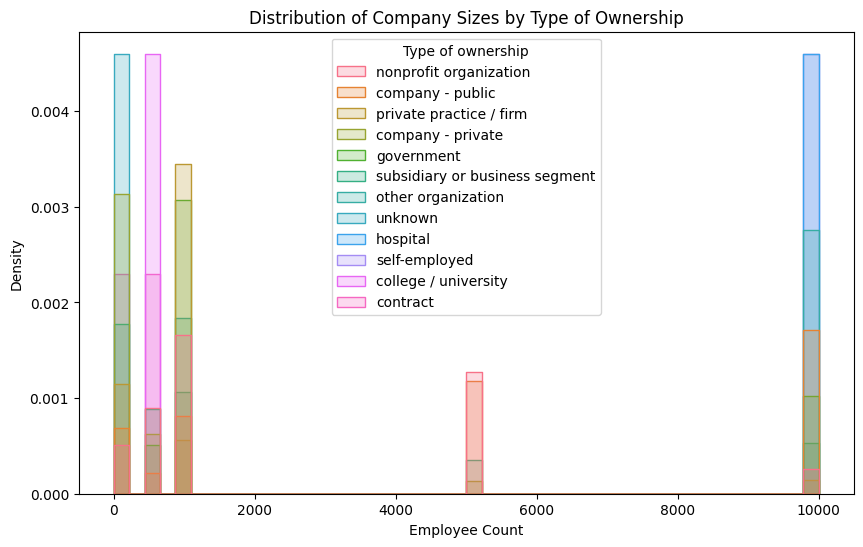

In [143]:
#1
#Basic Visualizations:

import matplotlib.pyplot as plt
import seaborn as sns

df['EmployeeSize'] = df['Size'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='EmployeeSize', hue='Type of ownership', element='step', stat='density', common_norm=False)
plt.title('Distribution of Company Sizes by Type of Ownership')
plt.xlabel('Employee Count')
plt.ylabel('Density')
plt.show()

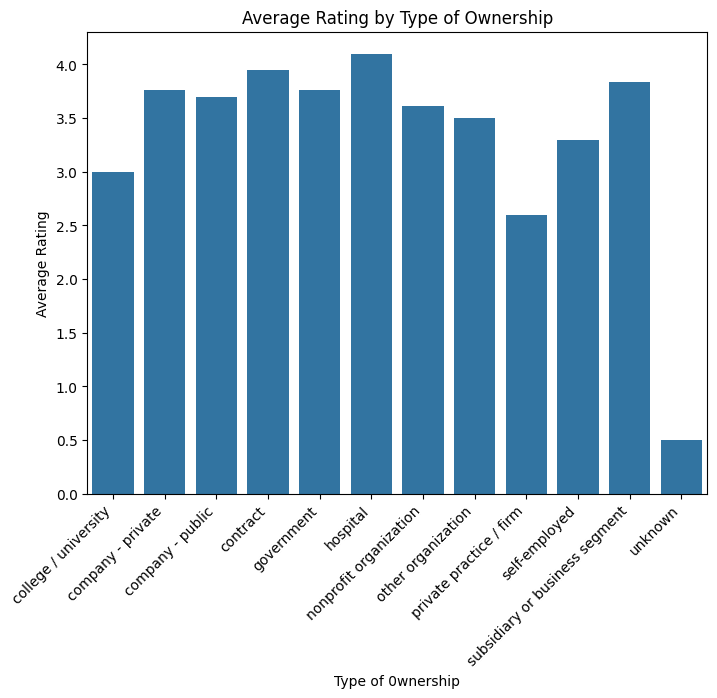

In [144]:

average_ratings = df.groupby('Type of ownership')['Rating'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=average_ratings, x='Type of ownership', y='Rating')
plt.title('Average Rating by Type of Ownership')
plt.xlabel('Type of 0wnership')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right') 
plt.show()

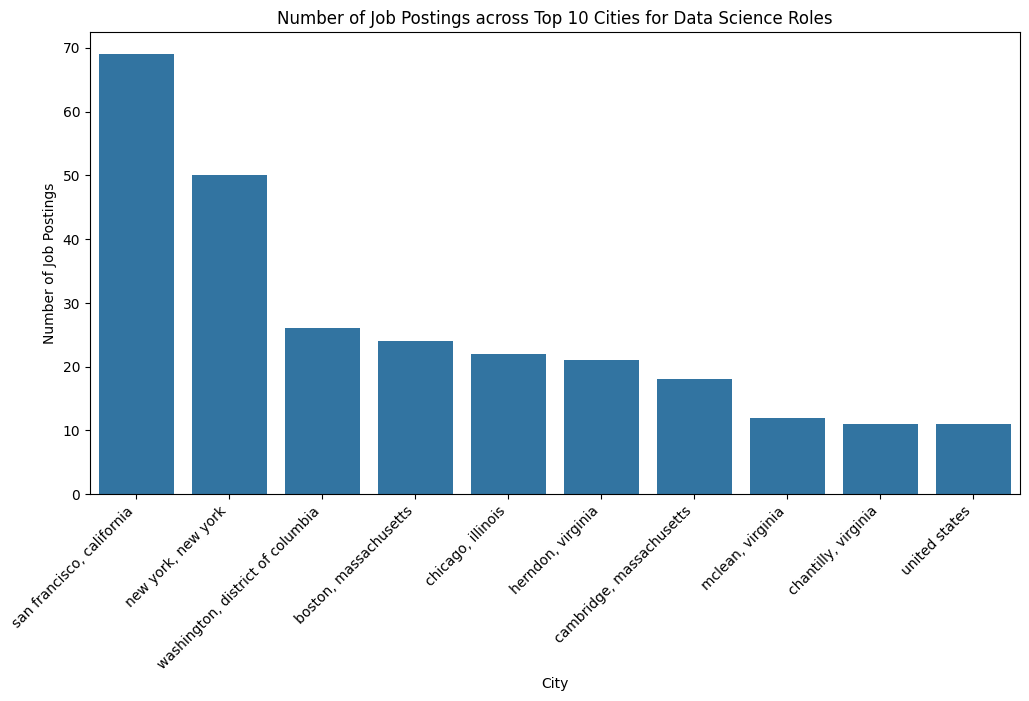

In [145]:
#2. Location-Based Visualizations:
top_10_cities = df['Location'].value_counts().head(10).index
filtered_df = df[df['Location'].isin(top_10_cities)]

plt.figure(figsize=(12, 6))
sns.countplot(data=filtered_df, x='Location', order=top_10_cities)
plt.title('Number of Job Postings across Top 10 Cities for Data Science Roles')
plt.xlabel('City')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45, ha='right') 
plt.show()

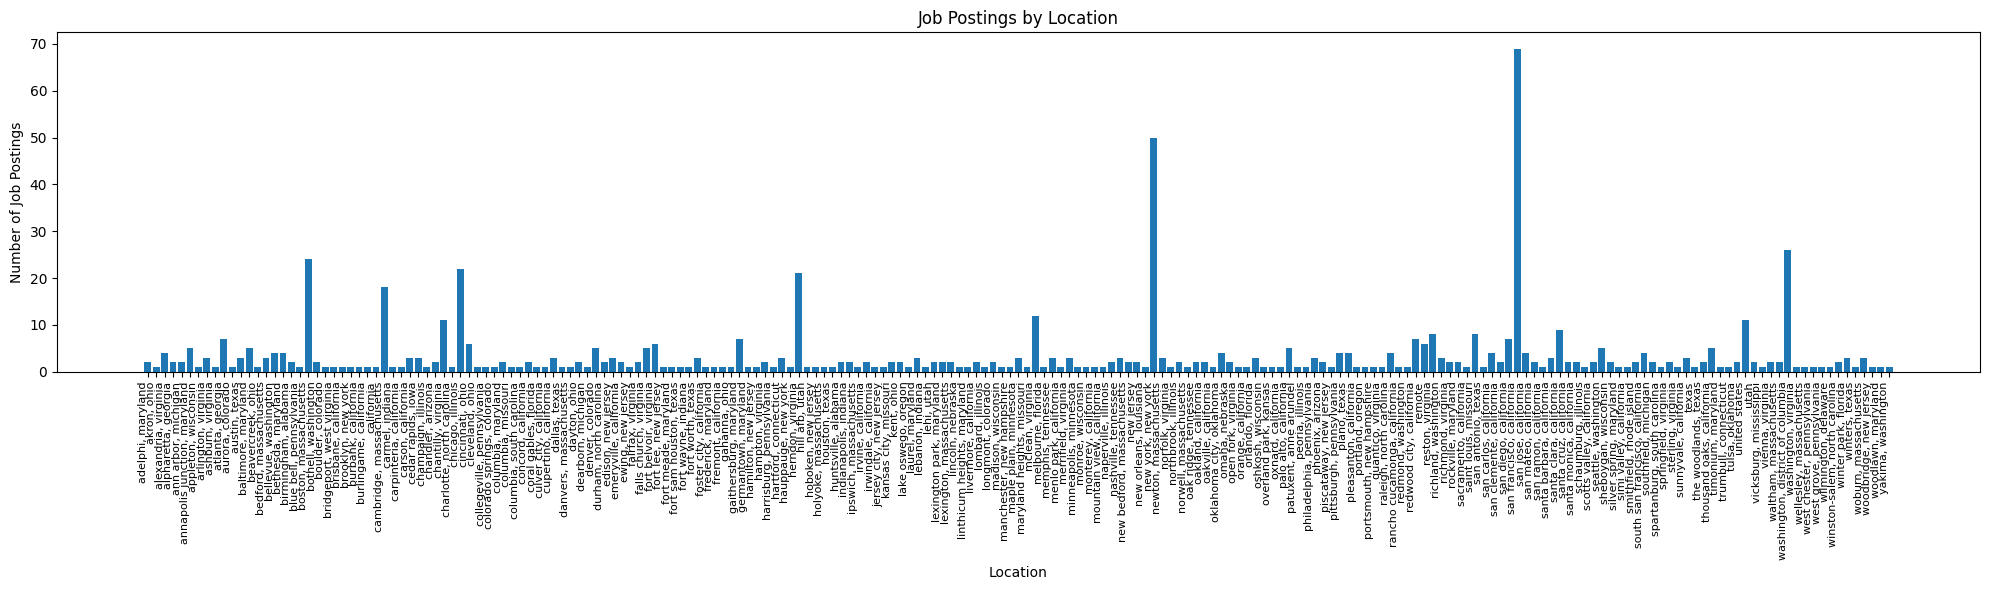

In [172]:


state_job_counts = df.groupby('Location').count().reset_index() 

state_job_counts = state_job_counts.rename(columns={state_job_counts.columns[1]: 'JobCount'})


 
plt.figure(figsize=(20, 6))
plt.bar(state_job_counts['Location'], state_job_counts['JobCount'])
plt.title('Job Postings by Location')
plt.xlabel('Location')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=90, ha='right', fontsize=8) 
plt.tight_layout()
plt.show()

UFuncTypeError: Cannot cast ufunc 'svd_n_s' input from dtype('O') to dtype('float64') with casting rule 'same_kind'

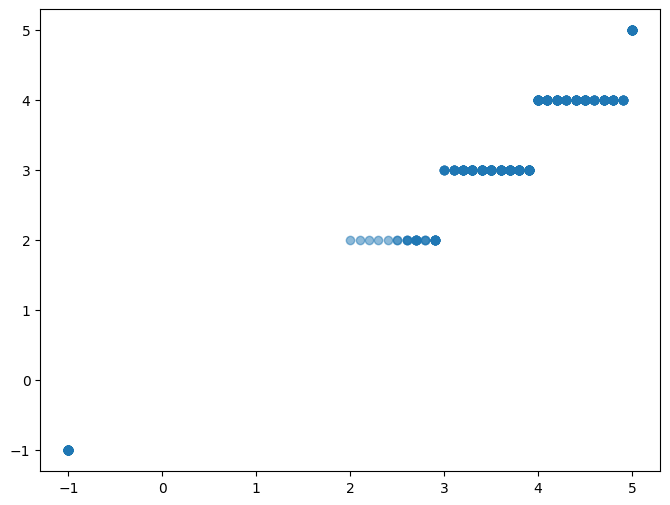

In [191]:
#3. Salary and Rating Analysis:


plt.figure(figsize=(8, 6))  
sns.regplot(data=df, x='Rating', y='Average Salary', scatter_kws={'alpha': 0.5}) 
plt.title('Relationship between Average Salary Range and Company Ratings')
plt.xlabel('Company Rating')
plt.ylabel('Average Salary Range')
plt.show()

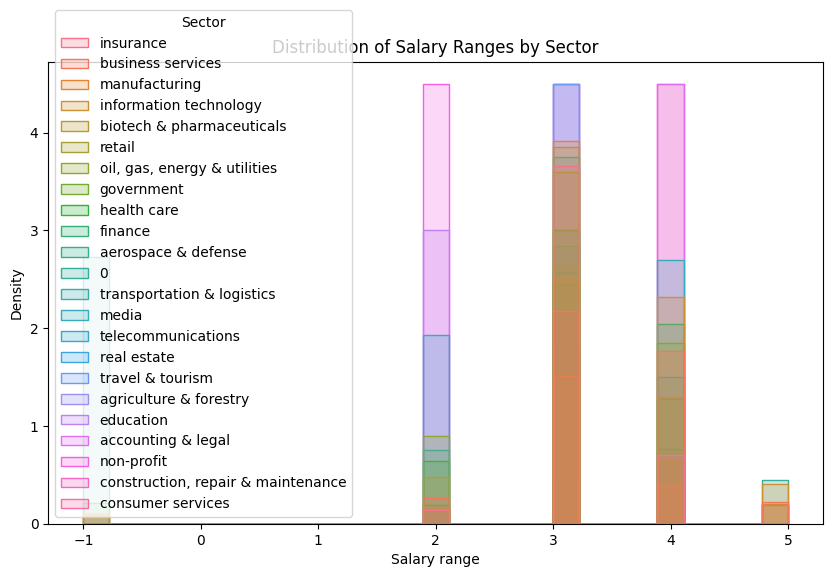

In [197]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Average Salary', hue='Sector', element='step', stat='density', common_norm=False)
plt.title('Distribution of Salary Ranges by Sector')
plt.xlabel('Salary range')
plt.ylabel('Density')
plt.show()

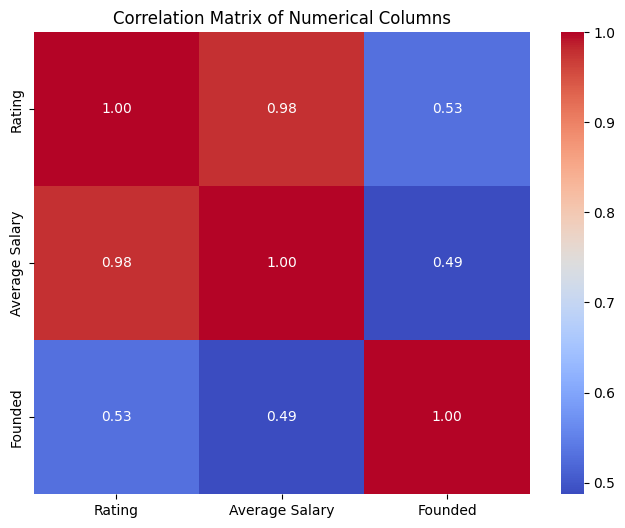

In [196]:

numerical_cols = ['Rating', 'Average Salary', 'Founded']  
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

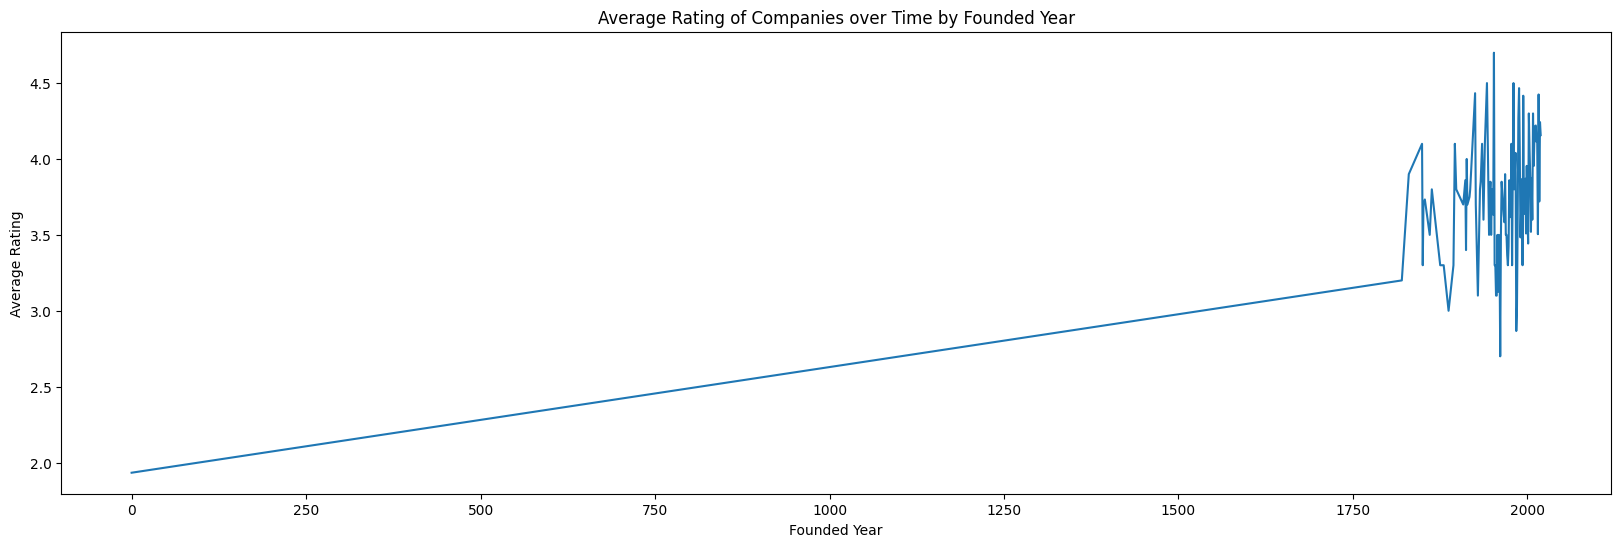

In [200]:
#4. Tricky Visualizations:

average_ratings_by_year = df.groupby('Founded')['Rating'].mean().reset_index()

# Create the line graph
plt.figure(figsize=(20, 6))  
sns.lineplot(data=average_ratings_by_year, x='Founded', y='Rating')
plt.title('Average Rating of Companies over Time by Founded Year')
plt.xlabel('Founded Year')
plt.ylabel('Average Rating')
plt.show()

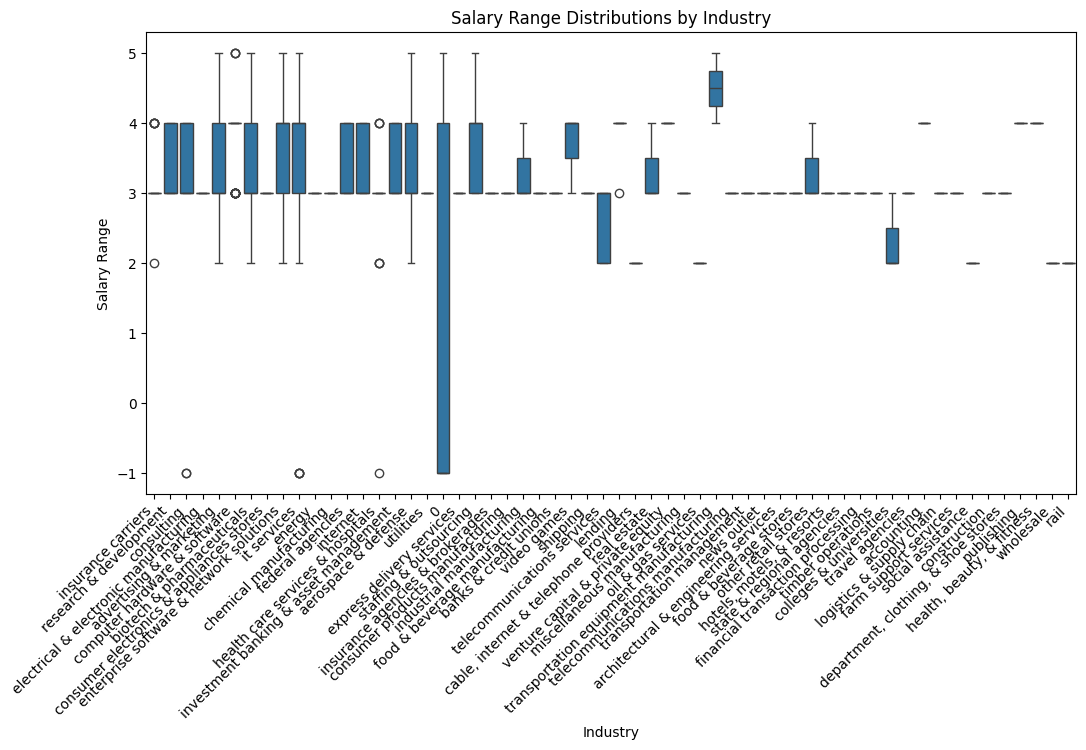

In [201]:


plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Industry', y='Average Salary')
plt.title('Salary Range Distributions by Industry')
plt.xlabel('Industry')
plt.ylabel('Salary Range')
plt.xticks(rotation=45, ha='right') 
plt.show()

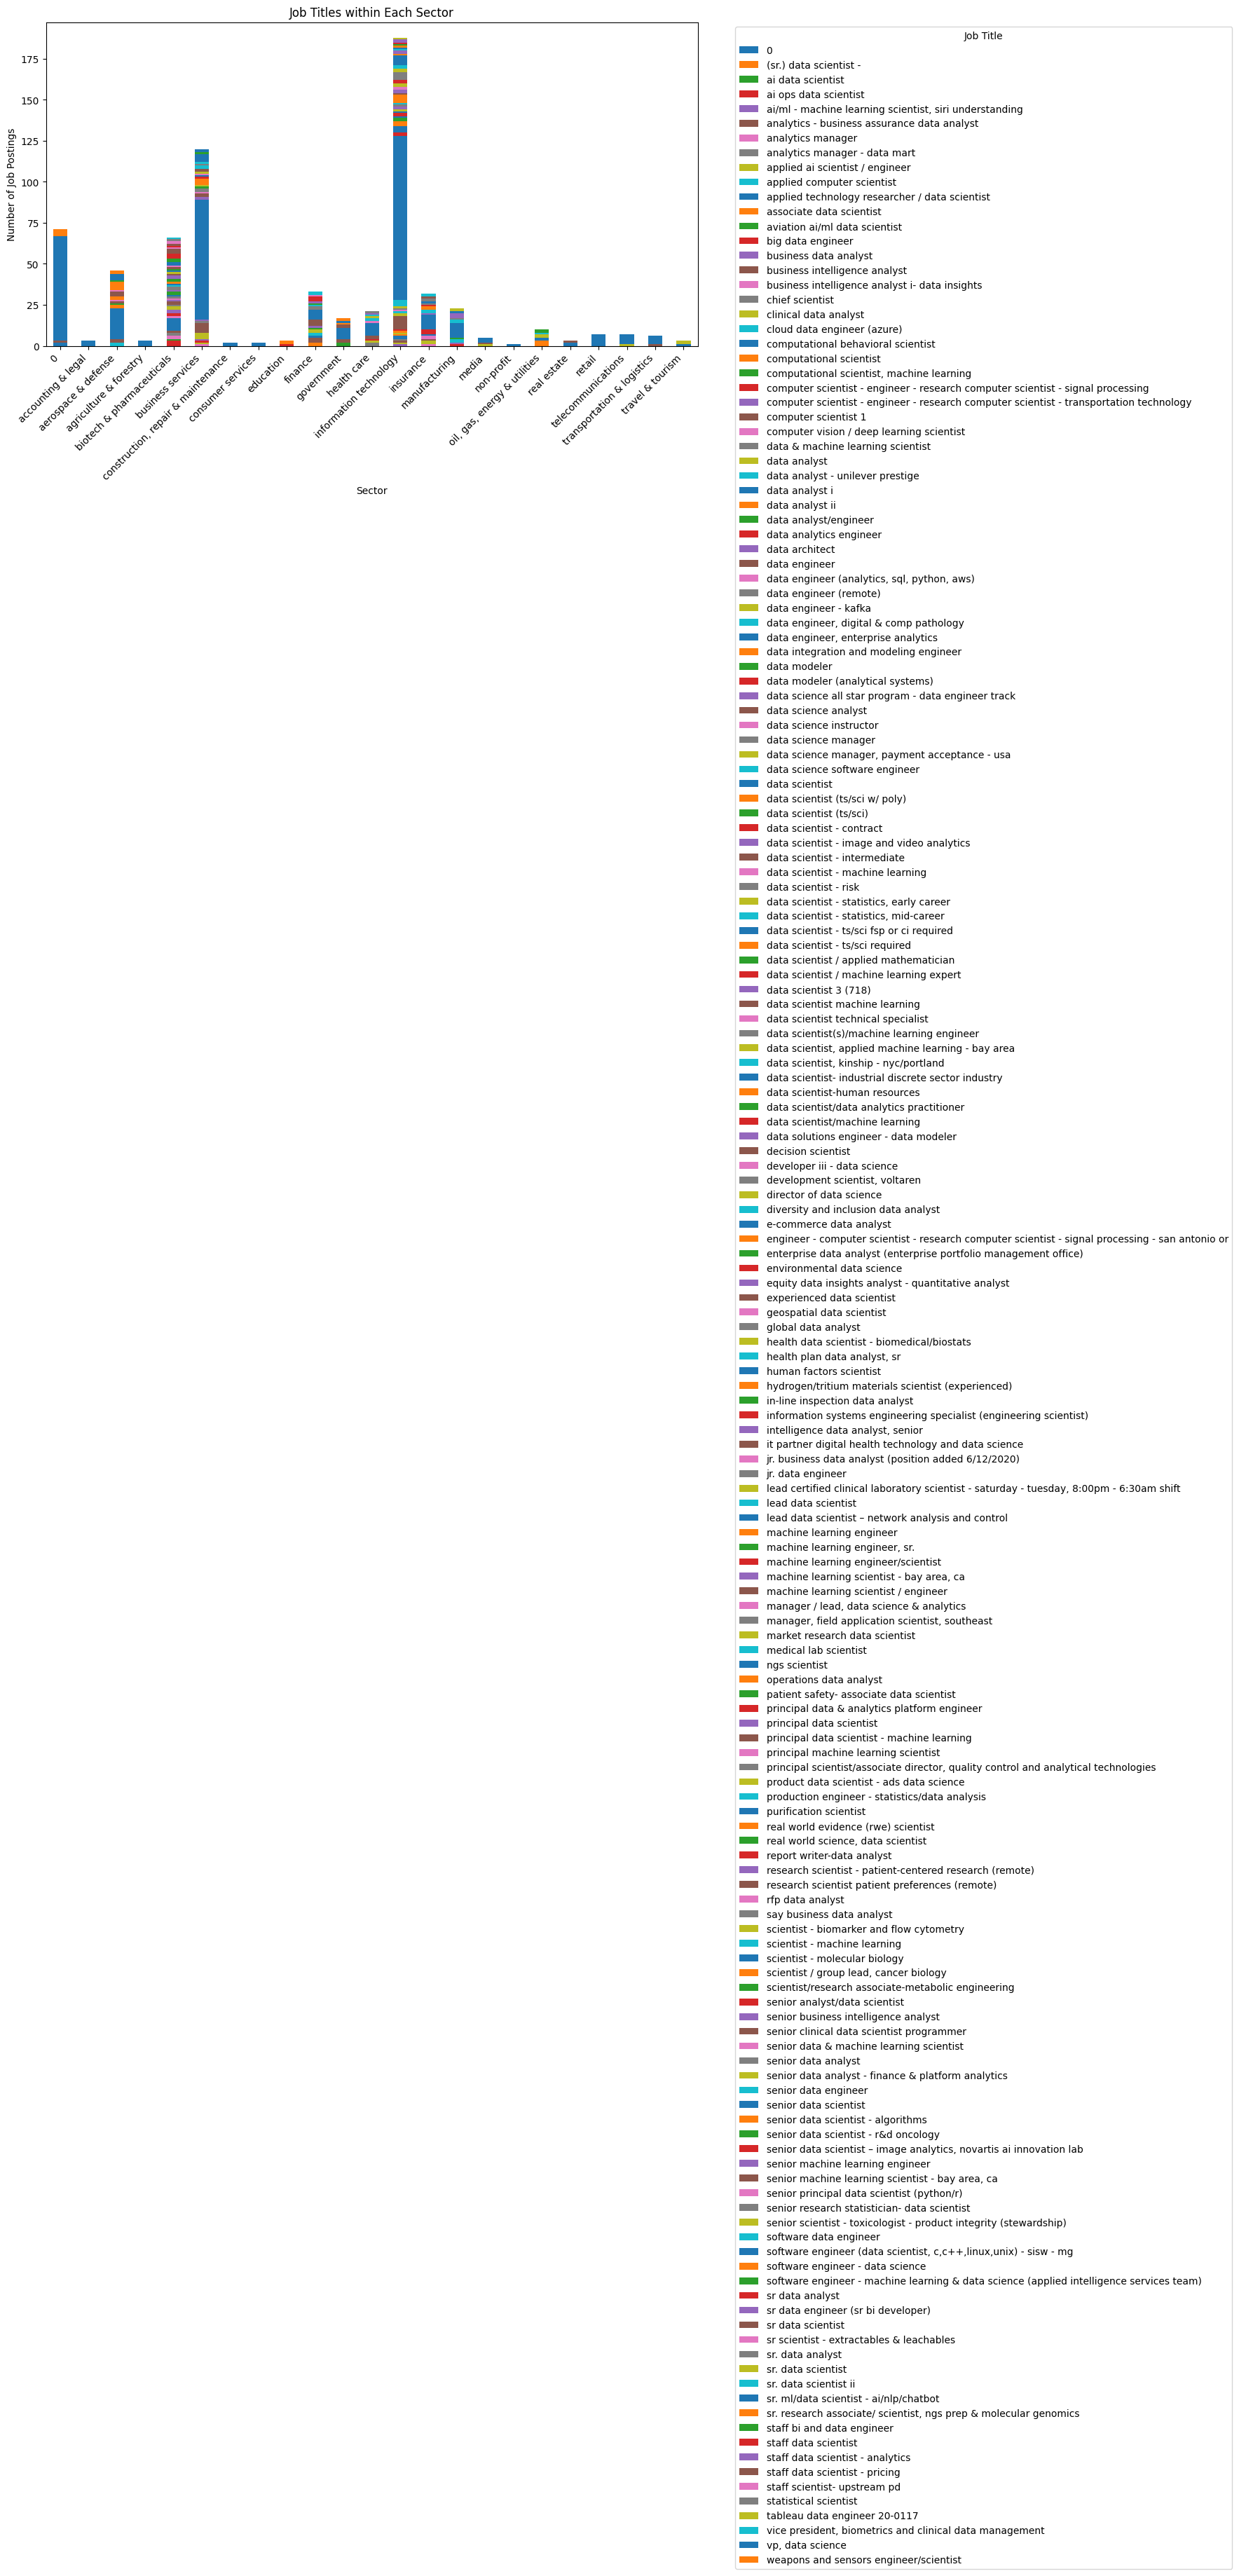

In [202]:
#
job_title_counts = df.groupby(['Sector', 'Job Title'])['Job Title'].count().reset_index(name='Count')

job_title_pivot = job_title_counts.pivot(index='Sector', columns='Job Title', values='Count').fillna(0)

job_title_pivot.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Job Titles within Each Sector')
plt.xlabel('Sector')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Job Title', bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.show()

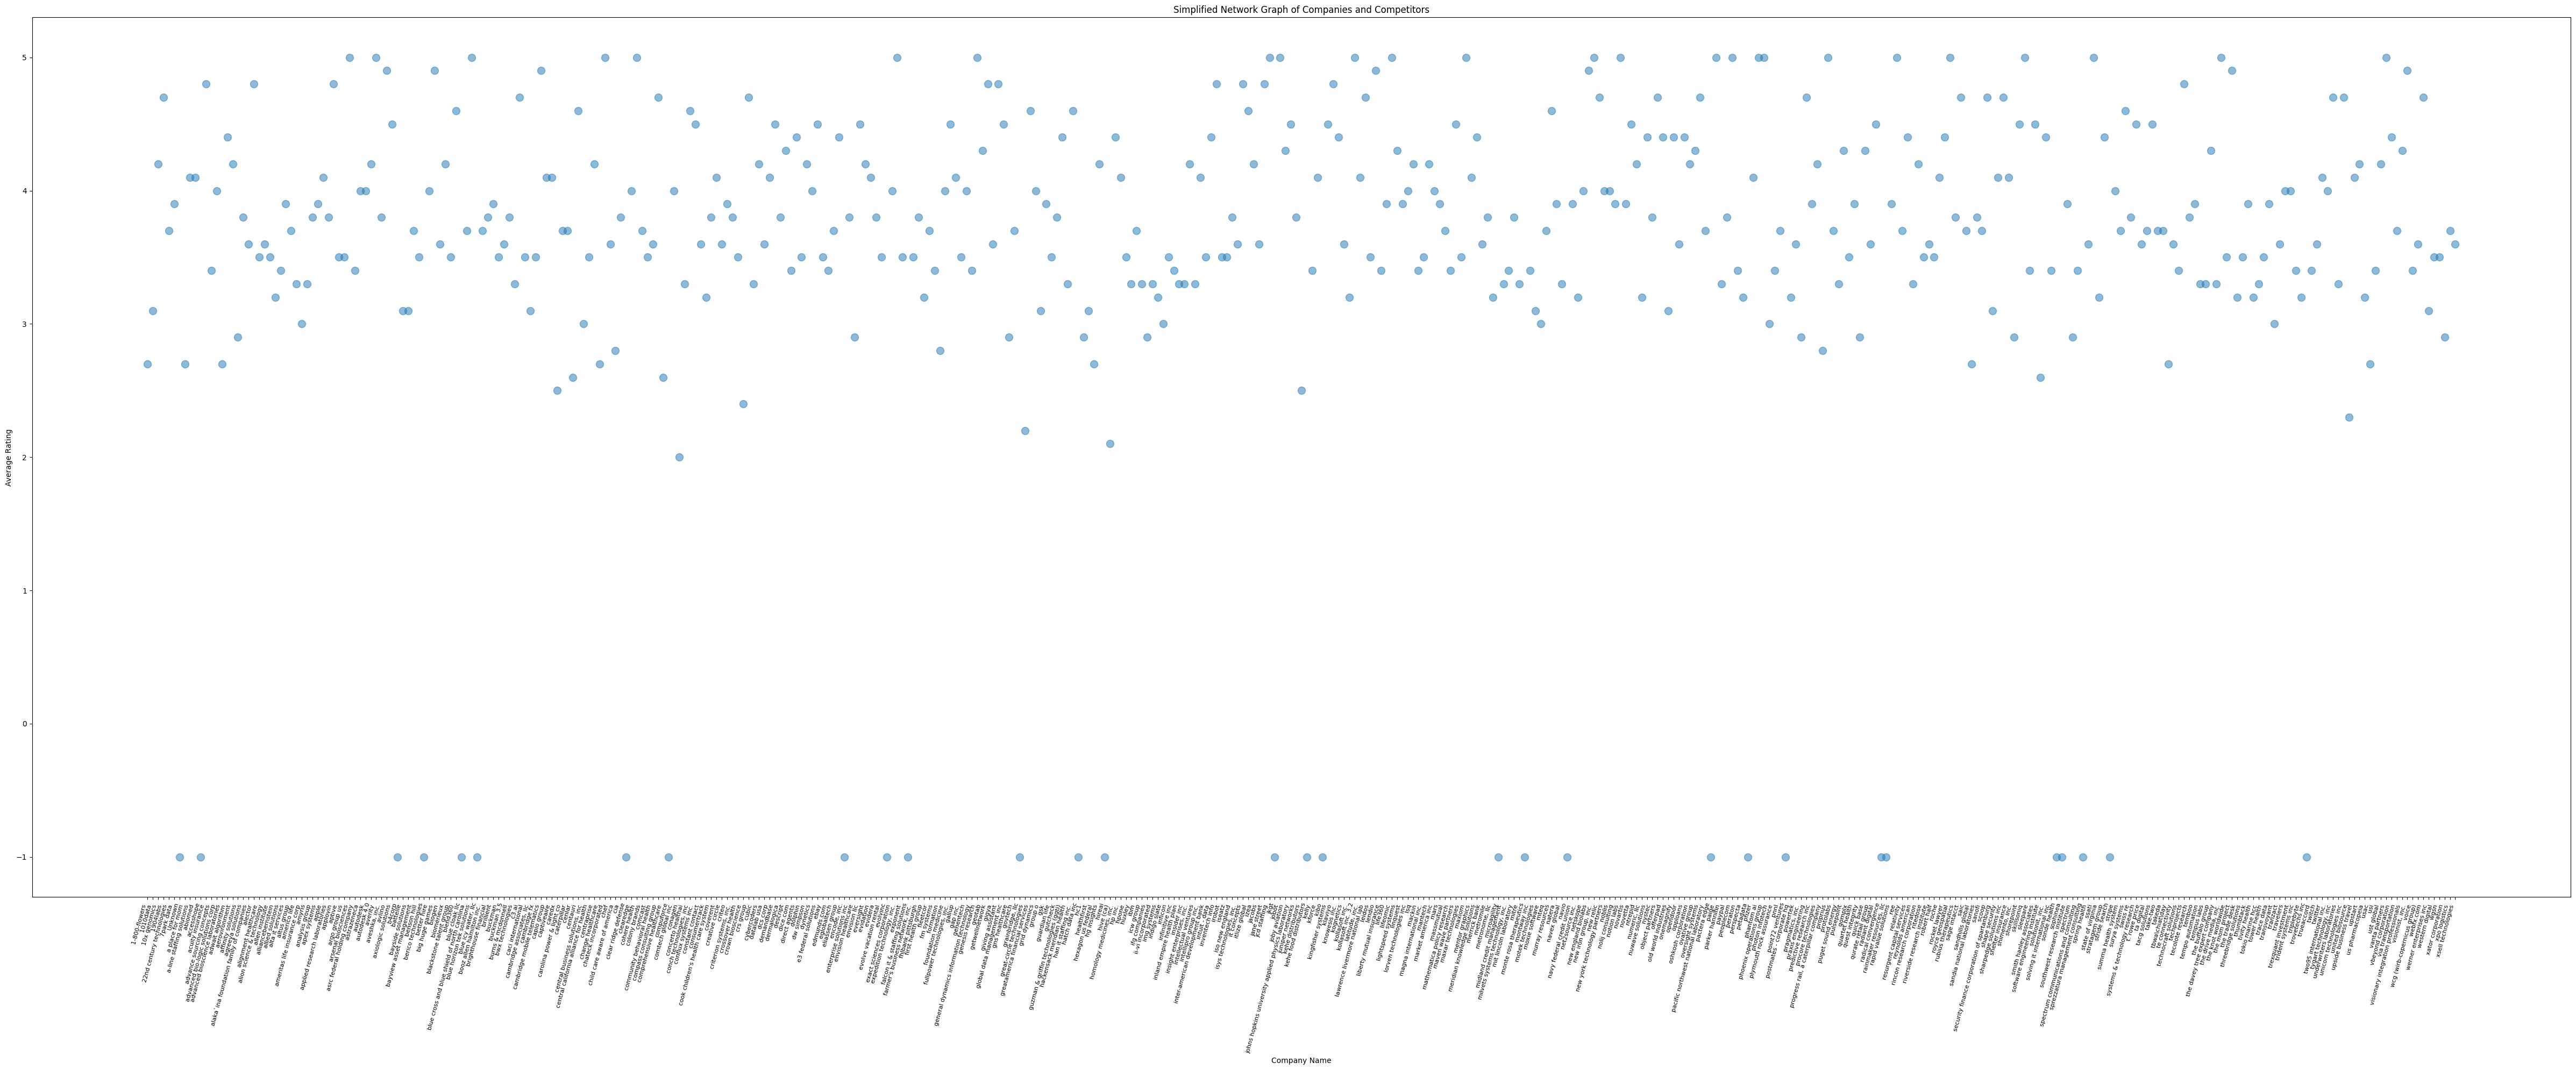

In [214]:
#5. Competitor and Popularity Insights:

company_ratings = df.groupby('Company Name')['Rating'].mean().reset_index()

company_index = {company: i for i, company in enumerate(company_ratings['Company Name'])}

edges = []
for index, row in df.iterrows():
    company = row['Company Name']
    competitors = row['Competitors'].split(', ') 
    for competitor in competitors:
        if competitor in company_index:
            edges.append((company_index[company], company_index[competitor]))

plt.figure(figsize=(48, 20)) 

x_coords = [i for i in range(len(company_ratings))]
y_coords = company_ratings['Rating']
plt.plot(x_coords, y_coords, 'o', markersize=10, alpha=0.5)  


for company1_index, company2_index in edges:
    plt.plot([company1_index, company2_index], [y_coords[company1_index], y_coords[company2_index]], alpha=0.3)

plt.xticks(x_coords, company_ratings['Company Name'], rotation=75, ha='right',fontsize=8)

plt.title('Simplified Network Graph of Companies and Competitors')
plt.xlabel('Company Name')
plt.ylabel('Average Rating')
plt.tight_layout()  
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, ' '),
  Text(1, 0, 'booz allen hamilton'),
  Text(2, 0, 'novartis'),
  Text(3, 0, 'glaxosmithkline'),
  Text(4, 0, 'roche'),
  Text(5, 0, 'slalom'),
  Text(6, 0, 'daugherty business solutions'),
  Text(7, 0, 'square'),
  Text(8, 0, 'paypal'),
  Text(9, 0, 'saic')])

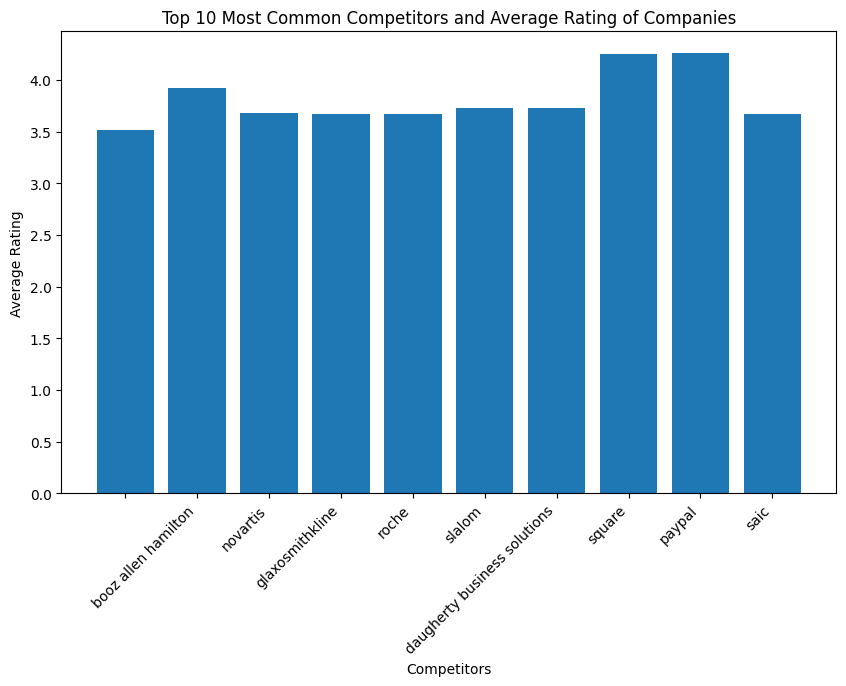

In [216]:

from collections import Counter

all_competitors = [
    competitor
    for sublist in df['Competitors'].str.split(', ')
    for competitor in sublist
    if competitor
]
competitor_counts = Counter(all_competitors)

top_10_competitors = [competitor for competitor, count in competitor_counts.most_common(10)]

average_ratings = []
for competitor in top_10_competitors:
    companies_with_competitor = df[df['Competitors'].str.contains(competitor, na=False)]['Company Name']
    average_rating = df[df['Company Name'].isin(companies_with_competitor)]['Rating'].mean()
    average_ratings.append(average_rating)

plt.figure(figsize=(10, 6))  
plt.bar(top_10_competitors, average_ratings)
plt.title('Top 10 Most Common Competitors and Average Rating of Companies')
plt.xlabel('Competitors')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')  

C:\Users\sebsn\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:241: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = ax.get_legend_handles_labels()
C:\Users\sebsn\AppData\Local\Temp\ipykernel_41988\2148423869.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  g.fig.show()


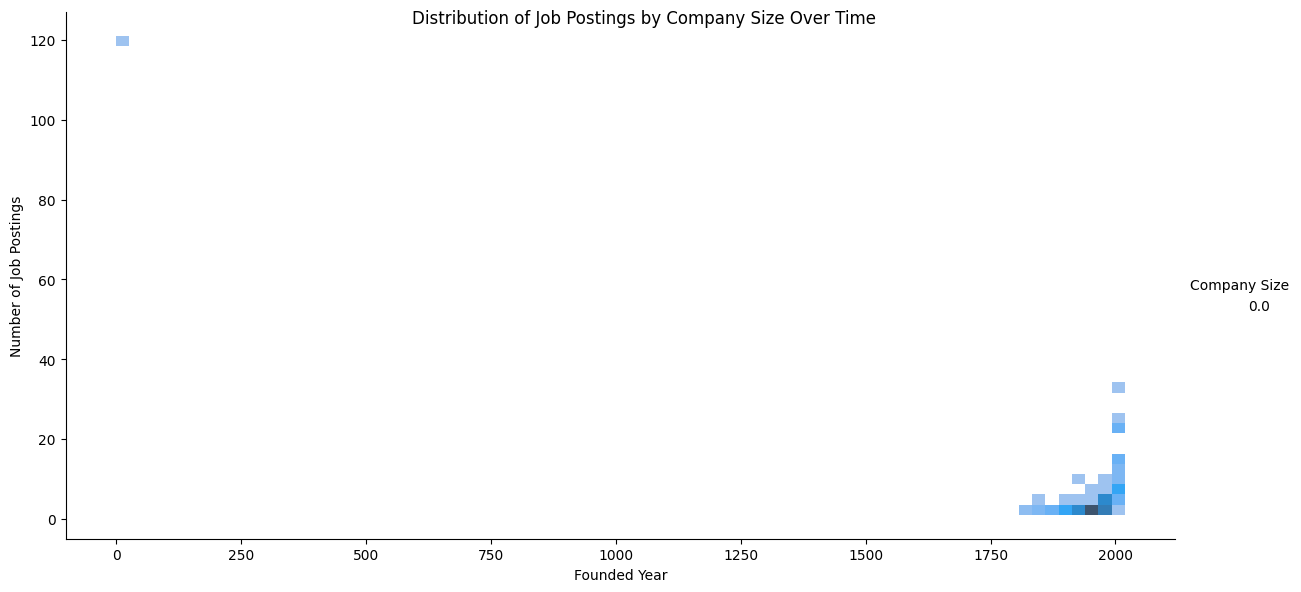

In [252]:
#6. Company and Industry Focused Visualizations:

size_over_time = df.groupby(['Founded', 'Size'])['Job Title'].count().reset_index()
size_over_time = size_over_time.pivot(index='Founded', columns='Size', values='Job Title').fillna(0)

melted_data = size_over_time.reset_index().melt(id_vars=['Founded'], value_name='Job Postings')

g = sns.FacetGrid(melted_data, hue='Size', height=6, aspect=2)  
g.map(sns.histplot, 'Founded', 'Job Postings', element="poly", fill=True, multiple="stack") 
g.add_legend(title='Company Size')

g.fig.suptitle('Distribution of Job Postings by Company Size Over Time') 
g.set_axis_labels("Founded Year", "Number of Job Postings")

g.fig.show()

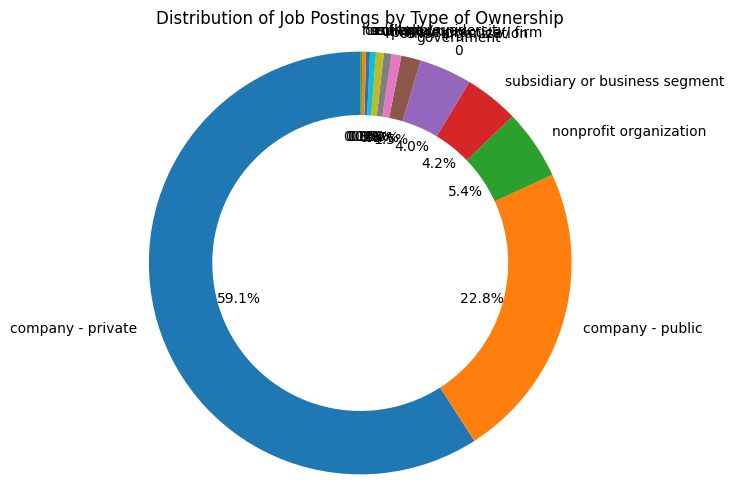

In [243]:

ownership_counts = df['Type of ownership'].value_counts()

plt.figure(figsize=(6, 6))  
plt.pie(ownership_counts, labels=ownership_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
plt.title('Distribution of Job Postings by Type of Ownership')
plt.axis('equal') 
plt.show()

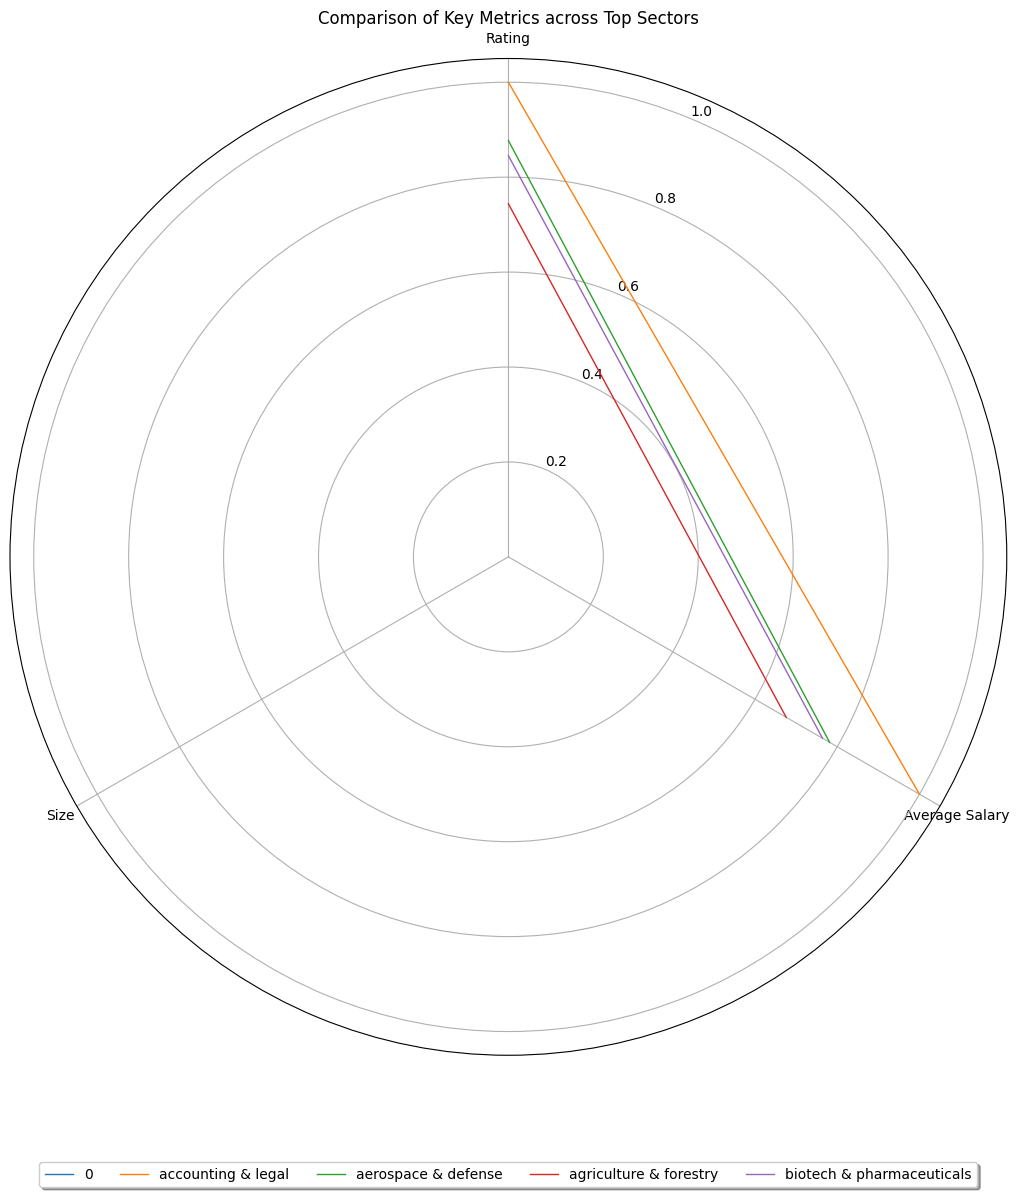

In [248]:

sector_metrics = df.groupby('Sector')[['Rating', 'Average Salary', 'Size']].mean().reset_index()

top_sectors = sector_metrics['Sector'].head(5).tolist()
sector_metrics = sector_metrics[sector_metrics['Sector'].isin(top_sectors)]

for metric in ['Rating', 'Average Salary', 'Size']:
    sector_metrics[metric] = (sector_metrics[metric] - sector_metrics[metric].min()) / (
        sector_metrics[metric].max() - sector_metrics[metric].min()
    )

num_metrics = len(['Rating', 'Average Salary', 'Size'])
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

for sector in top_sectors:
    values = sector_metrics[sector_metrics['Sector'] == sector][['Rating', 'Average Salary', 'Size']].values.flatten().tolist()
    values += values[:1]  
    ax.plot(angles, values, linewidth=1, linestyle='solid', label=sector)
    ax.fill(angles, values, alpha=0.25)


ax.set_theta_offset(np.pi / 2)  
ax.set_theta_direction(-1) 
ax.set_thetagrids(np.degrees(angles[:-1]), ['Rating', 'Average Salary', 'Size'])  
ax.set_rgrids([0.2, 0.4, 0.6, 0.8, 1.0])  
ax.set_title('Comparison of Key Metrics across Top Sectors')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), fancybox=True, shadow=True, ncol=5)  

plt.tight_layout()
plt.show()